# Function Declarations

Run once

In [708]:
from fairness_metric_utils import *
from penalty_utils import *
from weight_utils import *

In [709]:
def prepare_dataframe_for_attribute(dataset_path, attribute):
    """
    Load and prepare dataframe with specified attribute column.
    
    For combined attributes (e.g., 'sex-race'), creates the combined column 
    by concatenating individual attribute values and drops the individual columns.
    For single attributes, returns the dataframe as-is.
    
    Args:
        dataset_path: Path to the CSV file
        attribute: Single attribute (e.g., 'sex') or combined (e.g., 'sex-race')
    
    Returns:
        DataFrame with the attribute column prepared
    """
    df = pd.read_csv(dataset_path)
    
    # Check if this is a combined attribute
    individual_attrs = attribute.split('-')
    
    if len(individual_attrs) > 1:
        # Create combined column by concatenating individual attributes
        df[attribute] = reduce(
            lambda x, y: x.astype(str) + y.astype(str), 
            [df[col] for col in individual_attrs]
        )
        # Drop the individual attribute columns
        df = df.drop(columns=individual_attrs)
    
    return df

Select ONCE, the sensitive attribute for the rest of the dataset (WIP)

In [710]:
def get_acronym(full_name):
    """
    Convert full attribute value names to acronyms for plot labels.
    
    Args:
        full_name: Full name of the attribute value
    
    Returns:
        Acronym string
    """
    acronym_map = {
        'female': 'F',
        'male': 'M',
        'Amer-Black-Other': 'ABO',
        'Asian-White': 'AW',
        # Keep other values as-is or add more mappings as needed
    }
    return acronym_map.get(full_name, full_name)

## Plot Confusion Matrix

In [711]:
def plot_confusion_matrix(cm_data, forwhat='', sensible_attribute='', mapping={}):

    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    # Create figure with subplots for each subgroup
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Confusion Matrices by Subgroup: {sensible_attribute} {forwhat}', fontsize=16, fontweight='bold')

    # Flatten axes for easier iteration
    axes = axes.flatten()

    # Subgroups and their decoded labels
    subgroups = ['00', '01', '10', '11']
    individual_attrs = sensible_attribute.split('-')

    # Iterate through subgroups
    for idx, group in enumerate(subgroups):
        ax = axes[idx]
        
        if group in cm_data:
            cm = cm_data[group]
            
            # Create heatmap with counts
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                        cbar_kws={'label': 'Count'}, vmin=0,
                        xticklabels=['Pred Neg', 'Pred Pos'],
                        yticklabels=['True Neg', 'True Pos'])
            
            # Decode group label with acronyms
            attr1_val = mapping[individual_attrs[0]][int(group[0])]
            attr2_val = mapping[individual_attrs[1]][int(group[1])]
            
            # Calculate metrics for subtitle
            tn, fp, fn, tp = cm.ravel()
            total = tn + fp + fn + tp
            
            # Add text labels (TN, FP, FN, TP) on each cell
            labels = [['TN', 'FP'], ['FN', 'TP']]
            for i in range(2):
                for j in range(2):
                    text = ax.text(j + 0.5, i + 0.3, labels[i][j],
                                 ha='center', va='center',
                                 color='darkred', fontsize=7, fontweight='bold')
            
            # Title with decoded labels and sample count
            ax.set_title(f'Group {group}: {attr1_val} & {attr2_val}\n' + 
                        f'N = {total}',
                        fontweight='bold', fontsize=11)
            ax.set_xlabel('Predicted Label', fontsize=10)
            ax.set_ylabel('True Label', fontsize=10)
        else:
            # Handle missing subgroups
            ax.text(0.5, 0.5, f'Group {group}\nNo Data', 
                ha='center', va='center', fontsize=14, transform=ax.transAxes)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

## Weights Functions



### $w_i = 1 + \lambda * Penalty(g_i) $

In [712]:
# df = prepare_dataframe_for_attribute(dataset_path, sensible_attribute)

In [713]:
def compute_weights_notsized(lambda_=5.0, m='FPN', penalties_onval=None, X_train=None, sensible_attribute=None):
    print("lambda:", lambda_)
    train_df = X_train[sensible_attribute].copy()
    weights_for_training = np.ones(len(train_df))
    
    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100))
        for group, penalty in penalties_onval[m].items()
    }


    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_notsized = weights_for_training

    return weights_notsized


### $w_i = 1 + \lambda * Penalty(g_i) * \frac{|g_i|}{|G_{max}|} $

In [714]:
# df = prepare_dataframe_for_attribute(dataset_path, sensible_attribute)

In [715]:
def compute_weights_sized(lambda_=1.0, m='PPE', penalties_onval=None, X_train=None, sensible_attribute=None):

    train_df = X_train[sensible_attribute].copy()
    weights_for_training = np.ones(len(train_df))

    # # Calculate average weight per group from validation set
    # df['weight'] = weights
    group_counts2 = train_df[sensible_attribute].value_counts().to_dict() # |g_i| number of attribute value combinations for subgroup "group_col"
    max_group_size = max(group_counts2.values()) # |G_max| subgroup with the highest number of attribute value combinations (dimension)

    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100) * (group_counts2.get(group, 1)/max_group_size))
        for group, penalty in penalties_onval[m].items()
    }


    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_sized = weights_for_training

    return weights_sized

---

## Model 2: Fairness metrics and penalty after reweighting

## Function

To compute penalties for Model 2:
- **Actual value**: Fairness metric for `sex-race` using Model 2's predictions
- **Predicted value**: Harmonic mean of `sex` and `race` metrics using Model 2's predictions

**Weights were computed on validation set, then propagated to the training set based on group membership.** 

**Now we fit the model on training set with these weights and evaluate on test set.**

In [716]:
def compute_penalties_after_reweighting(weights, fairness_metric, dataset_path, sensible_attribute, X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels):
    # Train Model 2 ONLY on the combined attribute (sensible_attribute) with weights
    import xgboost as xgb
    attributes = sensible_attribute.split('-') + [sensible_attribute]
    fairness_metrics_dict_test_reweighed = {}

    for attribute in attributes:        
        df = prepare_dataframe_for_attribute(dataset_path, attribute)
        
        # Convert string combinations to numeric codes for XGBoost
        X_train_numeric = X_train[attribute].copy()
        X_train_numeric[attribute] = X_train_numeric[attribute].astype('category').cat.codes
        
        X_test_numeric = X_test[attribute].copy()
        X_test_numeric[attribute] = X_test_numeric[attribute].astype('category').cat.codes
        
        # Train model with weights on combined attribute
        model_reweighed = xgb.XGBClassifier(random_state=1234, eval_metric='logloss')
        model_reweighed.fit(X_train_numeric, y_train[attribute], sample_weight=weights)
        
        # Predict on test set
        y_pred_test_reweighed_combined = model_reweighed.predict(X_test_numeric)

        cm = confusion_matrix(y_test[attribute], y_pred_test_reweighed_combined, labels=target_variable_labels)
        
        # Compute sensible_indexes_test FRESH for this specific attribute
        sensible_indexes_test_attr = df[attribute].loc[list(X_test[attribute].index)]
        
        # Compute FAIRNESS METRICS for each attribute on TEST set
        # Use the SAME predictions (from combined attribute) for all attributes
        fairness_metrics_dict_test_reweighed[attribute], group_counts_test_reweighed, cm_dict_test_reweighed = \
        get_fairness_metrics(df, attribute, sensible_indexes_test_attr, \
        y_pred_test_reweighed_combined, y_test[attribute], X_test[attribute], \
        fair_metrics, dataset_path, mapping, target_variable_labels=['0', '1'])

    individual_attributes = sensible_attribute.split('-')
    df_original = pd.read_csv(dataset_path)

    penalties_ontest_reweighed_harmonic, penalties_ontest_reweighed_geometric, penalties_ontest_reweighed_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_test_reweighed, df_original, individual_attributes[0], individual_attributes[1], fairness_metric)

    return penalties_ontest_reweighed_harmonic

In [717]:
def performance_after_reweighting(weights, sensible_attribute, X_train, y_train, X_test, y_test): 
    import xgboost as xgb
    
    # Convert string combinations to numeric codes for XGBoost
    X_train_numeric = X_train[sensible_attribute].copy()
    X_train_numeric[sensible_attribute] = X_train_numeric[sensible_attribute].astype('category').cat.codes
    
    X_test_numeric = X_test[sensible_attribute].copy()
    X_test_numeric[sensible_attribute] = X_test_numeric[sensible_attribute].astype('category').cat.codes
    
    # Train model with weights on combined attribute
    model_reweighed = xgb.XGBClassifier(random_state=1234, eval_metric='logloss')
    model_reweighed.fit(X_train_numeric, y_train[sensible_attribute], sample_weight=weights)
    
    # Predict on test set
    y_pred_test_reweighed_combined = model_reweighed.predict(X_test_numeric)

    perf_metrics = performance_metrics(y_test[sensible_attribute], y_pred_test_reweighed_combined)
    
    return perf_metrics


### Plots

In [718]:
import matplotlib.pyplot as plt
import numpy as np

def plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping, lambd):
    """
    Generalized version that works with any subgroup combination.
    
    Args:
        fair_metrics: List of fairness metrics to plot
        penalties_ontest: Dictionary of penalties before reweighting {metric: {subgroup: penalty}}
        penalties_ontest_after_reweighting: Dictionary of penalties after reweighting
        sensible_attribute: String like 'age-edu', 'sex-race', etc.
        mapping: Dictionary mapping attribute codes to labels
    """
    # Extract subgroups (assuming all metrics have the same subgroups)
    subgroups = list(penalties_ontest[fair_metrics[0]].keys())
    
    # Parse the sensible_attribute to get individual attributes
    individual_attrs = sensible_attribute.split('-')
    
    # Set up the plot
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()

    # Create a bar plot for each metric
    for idx, metric in enumerate(fair_metrics):
        ax = axes[idx]
        
        # Extract penalties before and after for this metric
        penalties_before = [penalties_ontest[metric].get(group, 0) for group in subgroups]
        penalties_after = [penalties_ontest_after_reweighting[metric].get(group, 0) for group in subgroups]
        
        # Set up bar positions
        x = np.arange(len(subgroups))
        width = 0.35
        
        # Create bars
        bars1 = ax.bar(x - width/2, penalties_before, width, label='Before Reweighting', alpha=0.8, color='#e74c3c')
        bars2 = ax.bar(x + width/2, penalties_after, width, label='After Reweighting', alpha=0.8, color='#3498db')
        
        # Customize plot
        ax.set_xlabel('Subgroup', fontsize=10, fontweight='bold')
        ax.set_ylabel('Penalty (%)', fontsize=10, fontweight='bold')
        ax.set_title(f'{metric} Penalty Comparison', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        
        # Decode subgroup labels dynamically based on sensible_attribute with acronyms
        decoded_labels = []
        for group in subgroups:
            # Decode each character in the group code using corresponding attribute
            decoded_parts = []
            for i, attr in enumerate(individual_attrs):
                attr_code = int(group[i])
                attr_label = mapping[attr][attr_code]
                decoded_parts.append(attr_label)
            
            # Join with newline for multi-line labels
            decoded_labels.append('\n'.join(decoded_parts))
        
        ax.set_xticklabels(decoded_labels, fontsize=8)
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

    # Remove extra subplots if any
    for idx in range(len(fair_metrics), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.suptitle(f'Penalty Comparison: Before vs After Reweighting\nSubgroup: {sensible_attribute}, λ: {lambd}', 
                fontsize=16, fontweight='bold', y=1.03)
    plt.show()

In [719]:
# Individual plots for each metric (larger view for detailed inspection)
def plot_penalty_comparison_all_individual(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping, lambd):
    subgroups = list(penalties_ontest[fair_metrics[0]].keys())

    for metric in fair_metrics:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        
        # Extract penalties before and after for this metric
        penalties_before = [penalties_ontest[metric].get(group, 0) for group in subgroups]
        penalties_after = [penalties_ontest_after_reweighting[metric].get(group, 0) for group in subgroups]
        
        # Set up bar positions
        x = np.arange(len(subgroups))
        width = 0.35
        
        # Create bars
        bars1 = ax.bar(x - width/2, penalties_before, width, label='Before Reweighting', alpha=0.8, color='#e74c3c')
        bars2 = ax.bar(x + width/2, penalties_after, width, label='After Reweighting', alpha=0.8, color='#3498db')
        
        # Add value labels on bars
        for bar in bars1:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
        
        for bar in bars2:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
        
        individual_attrs = sensible_attribute.split('-')
        # Decode subgroup labels dynamically based on sensible_attribute with acronyms
        decoded_labels = []
        for group in subgroups:
            # Decode each character in the group code using corresponding attribute
            decoded_parts = []
            for i, attr in enumerate(individual_attrs):
                attr_code = int(group[i])
                attr_label = mapping[attr][attr_code]
                decoded_parts.append(attr_label)
            
            # Join with newline for multi-line labels
            decoded_labels.append('\n'.join(decoded_parts))
       
        
        # Customize plot
        ax.set_xlabel('Subgroup', fontsize=12, fontweight='bold')
        ax.set_ylabel('Penalty (%)', fontsize=12, fontweight='bold')
        ax.set_title(f'{metric} Penalty Comparison, λ: {lambd}', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(decoded_labels, fontsize=10)
        ax.legend(fontsize=11, loc='best')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
        
        plt.tight_layout()
        plt.show()
        print(f"\n{metric} - Penalty Changes:")
        for i, group in enumerate(subgroups):
            before = penalties_before[i]
            after = penalties_after[i]
            change = after - before
            print(f"  {decoded_labels[i].replace(chr(10), '-')}: {before:.2f} → {after:.2f} (Δ = {change:+.2f})")
        print("-" * 60)

In [720]:
def plot_penalty_comparison_lambdas(fairness_metric, lambdas, penalties_ontest, penalties_after_by_lambda, sensible_attribute, mapping):
    """
    Plot penalty comparison across different lambda values for a single fairness metric.
    
    Args:
        fairness_metric: Single fairness metric to plot (e.g., 'FPN')
        lambdas: List of lambda values
        penalties_ontest: Dictionary of penalties before reweighting {metric: {subgroup: penalty}}
        penalties_after_by_lambda: Dictionary mapping lambda to penalties after reweighting
                                  {lambda: {metric: {subgroup: penalty}}}
        sensible_attribute: String like 'age-edu', 'sex-race', etc.
        mapping: Dictionary mapping attribute codes to labels
    """
    # Extract subgroups
    subgroups = list(penalties_ontest[fairness_metric].keys())
    
    # Parse the sensible_attribute to get individual attributes
    individual_attrs = sensible_attribute.split('-')
    
    # Determine grid size based on number of lambdas
    n_lambdas = len(lambdas)
    if n_lambdas <= 3:
        nrows, ncols = 1, n_lambdas
    elif n_lambdas <= 6:
        nrows, ncols = 2, 3
    elif n_lambdas <= 9:
        nrows, ncols = 3, 3
    else:
        nrows, ncols = 3, 4
    
    # Set up the plot
    fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 5*nrows))
    if n_lambdas == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_lambdas > 1 else [axes]
    
    # Get penalties before reweighting (same for all lambdas)
    penalties_before = [penalties_ontest[fairness_metric].get(group, 0) for group in subgroups]
    
    # Create a bar plot for each lambda
    for idx, lambd in enumerate(lambdas):
        ax = axes[idx]
        
        # Extract penalties after for this lambda
        penalties_after = [penalties_after_by_lambda[lambd][fairness_metric].get(group, 0) for group in subgroups]
        
        # Set up bar positions
        x = np.arange(len(subgroups))
        width = 0.35
        
        # Create bars
        bars1 = ax.bar(x - width/2, penalties_before, width, label='Before Reweighting', alpha=0.8, color='#e74c3c')
        bars2 = ax.bar(x + width/2, penalties_after, width, label='After Reweighting', alpha=0.8, color='#3498db')
        
        # Add value labels on bars
        for bar in bars1:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)
        
        for bar in bars2:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)
        
        # Customize plot
        ax.set_xlabel('Subgroup', fontsize=10, fontweight='bold')
        ax.set_ylabel('Penalty (%)', fontsize=10, fontweight='bold')
        ax.set_title(f'λ = {lambd}', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        
        # Decode subgroup labels dynamically with acronyms
        decoded_labels = []
        for group in subgroups:
            decoded_parts = []
            for i, attr in enumerate(individual_attrs):
                attr_code = int(group[i])
                attr_label = mapping[attr][attr_code]
                decoded_parts.append(attr_label)
            decoded_labels.append('\n'.join(decoded_parts))
        
        ax.set_xticklabels(decoded_labels, fontsize=8)
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    
    # Remove extra subplots if any
    for idx in range(n_lambdas, len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.suptitle(f'Penalty Comparison Across Lambda Values\nMetric: {fairness_metric}, Subgroup: {sensible_attribute}', 
                fontsize=16, fontweight='bold', y=1.09)
    plt.show()

In [721]:
def get_distribution_data(df, sensible_attribute, target_variable, mapping):    
    # Step 1: Analyze Subgroup Distribution
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    # Load the full dataset
    df_analysis = pd.read_csv(dataset_path)

    # Create combined attribute column
    individual_attrs = sensible_attribute.split('-')
    df_analysis[sensible_attribute] = df_analysis[individual_attrs[0]].astype(str) + df_analysis[individual_attrs[1]].astype(str)

    # print("="*100)
    # print("SUBGROUP DISTRIBUTION ANALYSIS")
    # print("="*100)
    # print(f"\nDataset: {dataset_path}")
    # print(f"Total samples: {len(df_analysis)}")
    # print(f"Sensitive attribute: {sensible_attribute}")
    # print(f"Target variable: {target_variable}")

    # Get all subgroups
    subgroups = sorted(df_analysis[sensible_attribute].unique())

    # Create summary table
    # print("\n" + "-"*100)
    # print(f"{'Subgroup':<12} | {'Decoded':<25} | {'Total':>8} | {'Pos (y=1)':>10} | {'Neg (y=0)':>10} | {'Pos Rate':>10} | {'Balanced?':>10}")
    # print("-"*100)

    distribution_data = []

    for group in subgroups:
        # Decode the group with acronyms
        decoded = '-'.join([get_acronym(mapping[individual_attrs[i]][int(group[i])]) for i in range(len(individual_attrs))])
        
        # Get counts
        group_data = df_analysis[df_analysis[sensible_attribute] == group]
        total = len(group_data)
        positive = (group_data[target_variable] == 1).sum()
        negative = (group_data[target_variable] == 0).sum()
        pos_rate = positive / total if total > 0 else 0
        
        # Determine if balanced (within 40-60% range for positive rate)
        balanced = "Yes" if 0.3 <= pos_rate <= 0.7 else "No"
        
        # Check if we can extract 10+10 anchor samples
        can_anchor_10 = "✓" if positive >= 10 and negative >= 10 else "✗"
        
        distribution_data.append({
            'group': group,
            'decoded': decoded,
            'total': total,
            'positive': positive,
            'negative': negative,
            'pos_rate': pos_rate,
            'balanced': balanced,
            'can_anchor_10': can_anchor_10
        })
        
        # print(f"{group:<12} | {decoded:<25} | {total:>8} | {positive:>10} | {negative:>10} | {pos_rate:>9.1%} | {balanced:>10}")

    # print("-"*100)

    # # Summary statistics
    # print("\n" + "="*100)
    # print("FEASIBILITY CHECK: Can we extract anchor samples?")
    # print("="*100)

    # for n_anchor in [5, 10, 15, 20]:
    #     print(f"\n{n_anchor} positive + {n_anchor} negative per subgroup:")
    #     for d in distribution_data:
    #         can = "✓" if d['positive'] >= n_anchor and d['negative'] >= n_anchor else "✗"
    #         shortage_pos = max(0, n_anchor - d['positive'])
    #         shortage_neg = max(0, n_anchor - d['negative'])
    #         status = "OK" if can == "✓" else f"Need +{shortage_pos} pos, +{shortage_neg} neg"
    #         print(f"  {d['group']} ({d['decoded']:18s}): {can} {status}")   
            
    return distribution_data

In [722]:
def plot_subgroup_distribution(distribution_data, sensible_attribute):
    # Visualization: Subgroup Distribution
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Plot 1: Total samples per subgroup
    ax1 = axes[0]
    groups = [d['group'] for d in distribution_data]
    totals = [d['total'] for d in distribution_data]
    decoded_labels = [d['decoded'] for d in distribution_data]

    bars = ax1.bar(groups, totals, color=['#2ecc71', '#e74c3c', '#3498db', '#9b59b6'])
    ax1.set_xlabel('Subgroup')
    ax1.set_ylabel('Number of Samples')
    ax1.set_title('Total Samples per Subgroup')
    ax1.set_xticks(range(len(groups)))
    ax1.set_xticklabels([f"{g}\n({d})" for g, d in zip(groups, decoded_labels)], fontsize=9)

    # Add value labels on bars
    for bar, total in zip(bars, totals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                f'{total:,}', ha='center', va='bottom', fontsize=10)

    # Plot 2: Positive vs Negative per subgroup (stacked)
    ax2 = axes[1]
    positives = [d['positive'] for d in distribution_data]
    negatives = [d['negative'] for d in distribution_data]

    x = np.arange(len(groups))
    width = 0.6

    bars_neg = ax2.bar(x, negatives, width, label='Negative (y=0)', color='#3498db')
    bars_pos = ax2.bar(x, positives, width, bottom=negatives, label='Positive (y=1)', color='#e74c3c')

    ax2.set_xlabel('Subgroup')
    ax2.set_ylabel('Number of Samples')
    ax2.set_title('Positive vs Negative Labels per Subgroup')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f"{g}\n({d})" for g, d in zip(groups, decoded_labels)], fontsize=9)
    ax2.legend()

    # Plot 3: Positive rate per subgroup
    ax3 = axes[2]
    pos_rates = [d['pos_rate'] * 100 for d in distribution_data]

    bars = ax3.bar(groups, pos_rates, color=['#2ecc71' if 30 <= r <= 70 else '#e74c3c' for r in pos_rates])
    ax3.axhline(y=50, color='black', linestyle='--', linewidth=1, label='Balanced (50%)')
    ax3.axhline(y=30, color='gray', linestyle=':', linewidth=1)
    ax3.axhline(y=70, color='gray', linestyle=':', linewidth=1)
    ax3.set_xlabel('Subgroup')
    ax3.set_ylabel('Positive Rate (%)')
    ax3.set_title('Class Balance per Subgroup')
    ax3.set_xticks(range(len(groups)))
    ax3.set_xticklabels([f"{g}\n({d})" for g, d in zip(groups, decoded_labels)], fontsize=9)
    ax3.set_ylim(0, 100)
    ax3.legend()

    # Add value labels
    for bar, rate in zip(bars, pos_rates):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                f'{rate:.1f}%', ha='center', va='bottom', fontsize=10)

    plt.suptitle(f'Distribution Analysis: {sensible_attribute}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [723]:
from sklearn.model_selection import StratifiedKFold, KFold
import xgboost as xgb

def compute_penalties_kfold(sensible_attribute, fair_metrics, n_folds=5, verbose=True):
    """
    Compute penalties using K-Fold cross-validation for more stable estimates.
    
    Args:
        sensible_attribute: Combined attribute like 'sex-race'
        fair_metrics: List of fairness metrics to compute penalties for
        n_folds: Number of folds (default 5)
        verbose: Print progress
    
    Returns:
        penalties_kfold_avg: Dict of {metric: {subgroup: averaged_penalty}}
        penalties_per_fold: Dict of {metric: {subgroup: [penalties_per_fold]}}
    """
    attributes = sensible_attribute.split('-') + [sensible_attribute]
    individual_attrs = sensible_attribute.split('-')
    
    # Combine train + validation data
    X_trainval = pd.concat([X_train[sensible_attribute], X_val[sensible_attribute]])
    y_trainval = pd.concat([y_train[sensible_attribute], y_val[sensible_attribute]])
    
    if verbose:
        print("="*80)
        print(f"K-FOLD CROSS-VALIDATION FOR PENALTY ESTIMATION (K={n_folds})")
        print("="*80)
        print(f"Train+Val samples: {len(X_trainval)}")
        print(f"Test samples (held out): {len(X_test[sensible_attribute])}")
    
    # Initialize storage for penalties per fold
    penalties_per_fold = {m: {g: [] for g in ['00', '01', '10', '11']} for m in fair_metrics}

    # Setup stratified K-fold
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    # Load dataframe once for fairness computation
    df_original = pd.read_csv(dataset_path)
    
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval)):
        if verbose:
            print(f"\n--- Fold {fold_idx + 1}/{n_folds} ---")
        
        # Split data for this fold
        X_fold_train = X_trainval.iloc[train_idx]
        y_fold_train = y_trainval.iloc[train_idx]
        X_fold_val = X_trainval.iloc[val_idx]
        y_fold_val = y_trainval.iloc[val_idx]
        
        if verbose:
            # Show distribution in this fold's validation set
            val_dist = X_fold_val[sensible_attribute].value_counts().sort_index()
            print(f"  Val distribution: {val_dist.to_dict()}")
        
        # Convert to numeric for XGBoost
        X_fold_train_num = X_fold_train.copy()
        X_fold_train_num[sensible_attribute] = X_fold_train_num[sensible_attribute].astype('category').cat.codes
        
        X_fold_val_num = X_fold_val.copy()
        X_fold_val_num[sensible_attribute] = X_fold_val_num[sensible_attribute].astype('category').cat.codes

        # X_fold_train_num = X_fold_train.copy()
        # X_fold_val_num   = X_fold_val.copy()

        # cats = pd.Index(X_fold_train[sensible_attribute].astype(str).unique()).sort_values()
        # cat2code = {c: i for i, c in enumerate(cats)}

        # X_fold_train_num[sensible_attribute] = (
        #     X_fold_train[sensible_attribute].astype(str).map(cat2code).astype(int)
        # )
        # X_fold_val_num[sensible_attribute] = (
        #     X_fold_val[sensible_attribute].astype(str).map(cat2code).fillna(-1).astype(int)
        # )

        
        # Train model on this fold's training data
        model_fold = xgb.XGBClassifier(random_state=1234, eval_metric='logloss')
        model_fold.fit(X_fold_train_num, y_fold_train)
        
        # Predict on this fold's validation data
        y_pred_fold_val = model_fold.predict(X_fold_val_num)
        
        # Compute fairness metrics for each attribute
        fairness_metrics_fold = {}
        
        for attribute in attributes:
            df_attr = df_original.copy()
            
            if '-' in attribute:
                indiv_attrs = attribute.split('-')
                df_attr[attribute] = reduce(
                    lambda x, y: x.astype(str) + y.astype(str),
                    [df_attr[col] for col in indiv_attrs]
                )
            
            # Get sensible indexes for this fold's validation set
            sensible_indexes_fold = df_attr[attribute].loc[list(X_fold_val.index)]
            
            # Compute confusion matrix
            cm_dict_fold = compute_cm_group(
                df_attr, attribute, sensible_indexes_fold,
                y_pred_fold_val, y_fold_val, X_fold_val, target_variable_labels
            )
            
            # Compute fairness metrics
            fairness_metrics_fold[attribute] = {}
            for m in fair_metrics:
                fairness_metrics_fold[attribute][m], _ = compute_fairness_metrics_and_counts(
                    cm_dict_fold, m, attribute, mapping, dataset_path
                )
        
        # Compute penalties for each metric
        for m in fair_metrics:
            penalty_harm, _, _ = compute_penalty_2(
                fairness_metrics_fold, df_original,
                individual_attrs[0], individual_attrs[1], m
            )
            
            # Store penalty for each subgroup
            for group, penalty in penalty_harm.items():
                penalties_per_fold[m][group].append(penalty)
    
    # Average penalties across folds
    penalties_kfold_avg = {}
    for m in fair_metrics:
        penalties_kfold_avg[m] = {}
        for group in ['00', '01', '10', '11']:
            fold_penalties = penalties_per_fold[m][group]
            penalties_kfold_avg[m][group] = np.mean(fold_penalties)
    
    if verbose:
        print("\n" + "="*80)
        print("AVERAGED PENALTIES (across 5 folds)")
        print("="*80)
        for m in fair_metrics[:3]:  # Show first 3 metrics
            print(f"\n{m}:")
            for group in ['00', '01', '10', '11']:
                avg = penalties_kfold_avg[m][group]
                std = np.std(penalties_per_fold[m][group])
                fold_vals = penalties_per_fold[m][group]
                print(f"  {group}: avg={avg:+.2f}%, std={std:.2f}, folds={[f'{v:.1f}' for v in fold_vals]}")
    
    return penalties_kfold_avg, penalties_per_fold

In [724]:
def compute_weights_kfold(lambda_=5.0, m='PPE'):
    """
    Compute weights using K-fold averaged penalties instead of single-split penalties.
    """
    # Combine train + val for final training
    X_trainval = pd.concat([X_train[sensible_attribute], X_val[sensible_attribute]])
    y_trainval = pd.concat([y_train[sensible_attribute], y_val[sensible_attribute]])
    
    weights_for_training = np.ones(len(X_trainval))
    
    # Use K-fold averaged penalties
    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100))
        for group, penalty in penalties_kfold_avg[m].items()
    }
    
    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(X_trainval.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]
    
    print(f"Training samples: {len(weights_for_training)}, Weights per group (K-fold): {group_weights}")
    
    return weights_for_training, X_trainval, y_trainval

In [725]:
def compute_weights_kfold_sized(lambda_=5.0, m='PPE'):
    """
    Compute weights using K-fold averaged penalties instead of single-split penalties.
    """
    # Combine train + val for final training
    X_trainval = pd.concat([X_train[sensible_attribute], X_val[sensible_attribute]])
    y_trainval = pd.concat([y_train[sensible_attribute], y_val[sensible_attribute]])
    
    weights_for_training = np.ones(len(X_trainval))

    group_counts2 = train_df[sensible_attribute].value_counts().to_dict() # |g_i| number of attribute value combinations for subgroup "group_col"
    max_group_size = max(group_counts2.values()) # |G_max| subgroup with the highest number of attribute value combinations (dimension)
    
    # Use K-fold averaged penalties
    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100) * (group_counts2.get(group, 1)/max_group_size))
        for group, penalty in penalties_kfold_avg[m].items()
    }
    
    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(X_trainval.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]
    
    print(f"Training samples: {len(weights_for_training)}, Weights per group (K-fold): {group_weights}")
    
    return weights_for_training, X_trainval, y_trainval

In [726]:
def compute_penalties_after_reweighting_kfold(weights, X_trainval, y_trainval, fairness_metric, dataset_path, sensible_attribute, X_test, y_test, fair_metrics, mapping, target_variable_labels):
    """
    Train model on FULL train+val data with K-fold weights, evaluate on test set.
    """
    # Convert to numeric for XGBoost
    X_trainval_num = X_trainval.copy()
    X_trainval_num[sensible_attribute] = X_trainval_num[sensible_attribute].astype('category').cat.codes
    
    X_test_num = X_test[sensible_attribute].copy()
    X_test_num[sensible_attribute] = X_test_num[sensible_attribute].astype('category').cat.codes
    
    # Train model on full train+val with weights
    model_kfold = xgb.XGBClassifier(random_state=1234, eval_metric='logloss')
    model_kfold.fit(X_trainval_num, y_trainval, sample_weight=weights)
    
    # Predict on test set
    y_pred_test_kfold = model_kfold.predict(X_test_num)
    
    # Compute fairness metrics
    attributes = sensible_attribute.split('-') + [sensible_attribute]
    individual_attrs = sensible_attribute.split('-')
    df_fresh = pd.read_csv(dataset_path)
    
    fairness_metrics_kfold = {}
    
    for attribute in attributes:
        df_attr = df_fresh.copy()
        
        if '-' in attribute:
            indiv_attrs = attribute.split('-')
            df_attr[attribute] = reduce(
                lambda x, y: x.astype(str) + y.astype(str),
                [df_attr[col] for col in indiv_attrs]
            )
        
        sensible_indexes_attr = df_attr[attribute].loc[list(X_test[sensible_attribute].index)]
        
        cm_dict_attr = compute_cm_group(
            df_attr, attribute, sensible_indexes_attr,
            y_pred_test_kfold, y_test[sensible_attribute], X_test[sensible_attribute],
            target_variable_labels
        )
        
        fairness_metrics_kfold[attribute] = {}
        for m in fair_metrics:
            fairness_metrics_kfold[attribute][m], _ = compute_fairness_metrics_and_counts(
                cm_dict_attr, m, attribute, mapping, dataset_path
            )
    
    # Compute penalties
    harmonic, _, _ = compute_penalty_2(
        fairness_metrics_kfold, df_fresh,
        individual_attrs[0], individual_attrs[1],
        fairness_metric
    )
    
    return harmonic

# Experiment Runs

# ADULT CENSUS

## Parameters

Made so they can be easily changed

In [727]:
# Flags
ALL_FM_L_NOTSIZED = 0  # Set to 1 to plot all fairness metrics specified in 'fair_metrics' for all lambdas in 'lambdas' when using notsized weights
SIZED = 0 # Set to 1 to add plots using sized weights
ALL_FM_L_SIZED = 0  # Set to 1 to plot all fairness metrics specified in 'fair_metrics' for all lambdas in 'lambdas' when using sized weights

In [728]:
datasets = {0: 'AdultCensus/adult-preprocessed-2race-2age-2edu.csv', 
            1: 'COMPAS/compas-preprocessed-binary.csv', 
            2: 'GermanCredit/german-preprocessed-binary.csv'}

dataset_path = datasets[0]

In [729]:
sensible_attribute = 'sex-race'

In [730]:
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

models = {
    'xgb': xgb.XGBClassifier(random_state=1234, eval_metric='logloss'),
    'lgbm': lgb.LGBMClassifier(random_state=1234, verbose=-1),
    'cb': cb.CatBoostClassifier(random_state=1234, verbose=False)
  }

selected_model = models['lgbm']

In [731]:
# ['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
fair_metrics = ['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']

In [732]:
lambdas = [0.5, 1.0, 2.0, 5.0, 10.0]

In [733]:
fixed_lambda = 1.0

In [734]:
attributes = sensible_attribute.split('-') + [sensible_attribute]
print(attributes)

['sex', 'race', 'sex-race']


In [735]:
import pandas as pd

df=pd.read_csv(dataset_path)

if dataset_path == datasets[0]:  # Adult Census
    protected_attributes =['age', 'sex', 'race', 'edu']
    mapping= {
        'age':{
            0: 'young',
            1: 'adult'
        },
        'edu':{
            0: 'low-edu',
            1: 'high-edu'
        },
        'sex':{
            0: 'female',
            1: 'male'
        },
        'race':{
            0: 'Amer-Black-Other',
            1: 'Asian-White'
        }
    }
    feature_cols= df.columns
    target_variable = 'income'
elif dataset_path == datasets[1]:  # COMPAS
    protected_attributes =['age', 'sex', 'race']
    mapping= {
        'age':{
            0: 'age<35',
            1: 'age>35',
        },
        'sex':{
            0: 'fem',
            1: 'mal'
        },
        'race':{
            0: 'African',
            1: 'AsiaWhiHispNatOth'
        }
    }
    feature_cols= df.columns
    target_variable = 'is_violent_recid'
elif dataset_path == datasets[2]:  # German Credit
    protected_attributes =['age', 'sex']
    mapping= {
        'age':{
            0: 'young',
            1: 'adult'
        },
        'sex':{
            0: 'female',
            1: 'male'
        }
    }
    feature_cols= df.columns
    target_variable = 'risk'

target_variable_labels= ['0','1']
df.head()

,age,edu,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,1,0,6,1,1,0,0,4356,40,0
1,1,0,6,1,1,0,0,4356,18,0
2,1,1,6,4,0,0,0,4356,40,0
3,1,0,0,4,1,0,0,3900,40,0
4,1,1,5,3,1,0,0,3900,40,0


# Compute Fairness Metrics: Validation and Test

Using a model that predicts on validation set, and another that predicts on test set

In [736]:
# Data Split variables
X_train = {}
y_train = {}
X_val = {}    # Validation set (used for computing fairness metrics, weights)
y_val = {}
X_test = {}   # Test set (unseen, used for final evaluation)
y_test = {}

# Validation set variables
y_pred_val = {}   # Predictions on validation set
fairness_metrics_dict_val= {}
cm_val = {}
cm_dict_val = {}
group_counts_val = {}
model_baseline_val = {}
performance_metrics_val = {}

# Test set variables
y_pred_test = {}   # Predictions on test set
fairness_metrics_dict_test= {}
cm_test = {}
cm_dict_test = {}
group_counts_test = {}
model_baseline_test = {}
performance_metrics_test = {}

for attribute in attributes:
    df = prepare_dataframe_for_attribute(dataset_path, attribute)

    # Compute DATA SPLIT for each attribute: TRAINING, VALIDATION, TEST
    sensible_indexes_val, sensible_indexes_test, X_train[attribute], y_train[attribute], X_val[attribute], y_val[attribute], X_test[attribute], y_test[attribute] = \
    compute_data_split(df, target_variable, attribute)

    # Compute MODEL PREDICTIONS for each attribute, on VALIDATION set | Model 1A
    y_pred_val[attribute], cm_val[attribute], model_baseline_val[attribute], performance_metrics_val[attribute] = \
    compute_model_predictions_general(X_train[attribute], y_train[attribute], X_val[attribute], y_val[attribute], \
                              target_variable_labels, attribute, selected_model)

    # Compute FAIRNESS METRICS for each attribute, on VALIDATION set
    fairness_metrics_dict_val[attribute], group_counts_val[attribute], cm_dict_val[attribute] = \
                                    get_fairness_metrics(df, attribute, sensible_indexes_val, \
                                    y_pred_val[attribute], y_val[attribute], X_val[attribute], \
                                    fair_metrics, dataset_path, mapping, target_variable_labels=['0','1'])
    
    # Compute MODEL PREDICTIONS for each attribute, on TEST set | Model 1B
    y_pred_test[attribute], cm_test[attribute], model_baseline_test[attribute], performance_metrics_test[attribute] = \
    compute_model_predictions_general(X_train[attribute], y_train[attribute], X_test[attribute], y_test[attribute], \
                                      target_variable_labels, attribute, selected_model)

    # Compute FAIRNESS METRICS for each attribute, on TEST set
    fairness_metrics_dict_test[attribute], group_counts_test[attribute], cm_dict_test[attribute] = \
                                    get_fairness_metrics(df, attribute, sensible_indexes_test, \
                                    y_pred_test[attribute], y_test[attribute], X_test[attribute], \
                                    fair_metrics, dataset_path, mapping, target_variable_labels=['0', '1'])


sex
Precision: 0.7604166666666666, Recall: 0.6108786610878661, Accuracy: 0.8576986076986077, F1: 0.6774941995359629
{np.int64(0): array([[1447,   21],
       [  82,   99]]), np.int64(1): array([[2012,  209],
       [ 383,  631]])}
sex
Precision: 0.7746062992125984, Recall: 0.6525704809286899, Accuracy: 0.8673490276356193, F1: 0.7083708370837084
{np.int64(0): array([[1407,   23],
       [  86,   94]]), np.int64(1): array([[2043,  206],
       [ 333,  693]])}
race
Precision: 0.7604166666666666, Recall: 0.6108786610878661, Accuracy: 0.8576986076986077, F1: 0.6774941995359629
{np.int64(1): array([[2987,  224],
       [ 428,  701]]), np.int64(0): array([[472,   6],
       [ 37,  29]])}
race
Precision: 0.7746062992125984, Recall: 0.6525704809286899, Accuracy: 0.8673490276356193, F1: 0.7083708370837084
{np.int64(1): array([[2965,  220],
       [ 373,  757]]), np.int64(0): array([[485,   9],
       [ 46,  30]])}
sex-race
Precision: 0.7596656217345873, Recall: 0.6083682008368201, Accuracy: 0.85

In [737]:
# Compute BASELINE penalties on TEST set (Model 1 predictions)
penalties_ontest = {}
penalties_onval = {}
df_original = pd.read_csv(dataset_path)
individual_attributes = sensible_attribute.split('-')

for m in fair_metrics:
    # penalty_harm, penalty_geom, penalty_arith = compute_penalty_2(
    #     fairness_metrics_ontest_full, df_combined, 'sex', 'race', m
    # )
    penalties_ontest_harmonic, penalties_ontest_geometric, penalties_ontest_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_test, df_original, individual_attributes[0], individual_attributes[1], m)

    penalties_ontest[m] = penalties_ontest_harmonic


    penalties_onval_harmonic, penalties_onval_geometric, penalties_onval_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_val, df_original, individual_attributes[0], individual_attributes[1], m)
    
    penalties_onval[m] = penalties_onval_harmonic
    
    # penalties_ontest[m] = {
    #     'harmonic': penalty_harm
    #     'geometric': penalty_geom,
    #     'arithmetic': penalty_arith
    # }

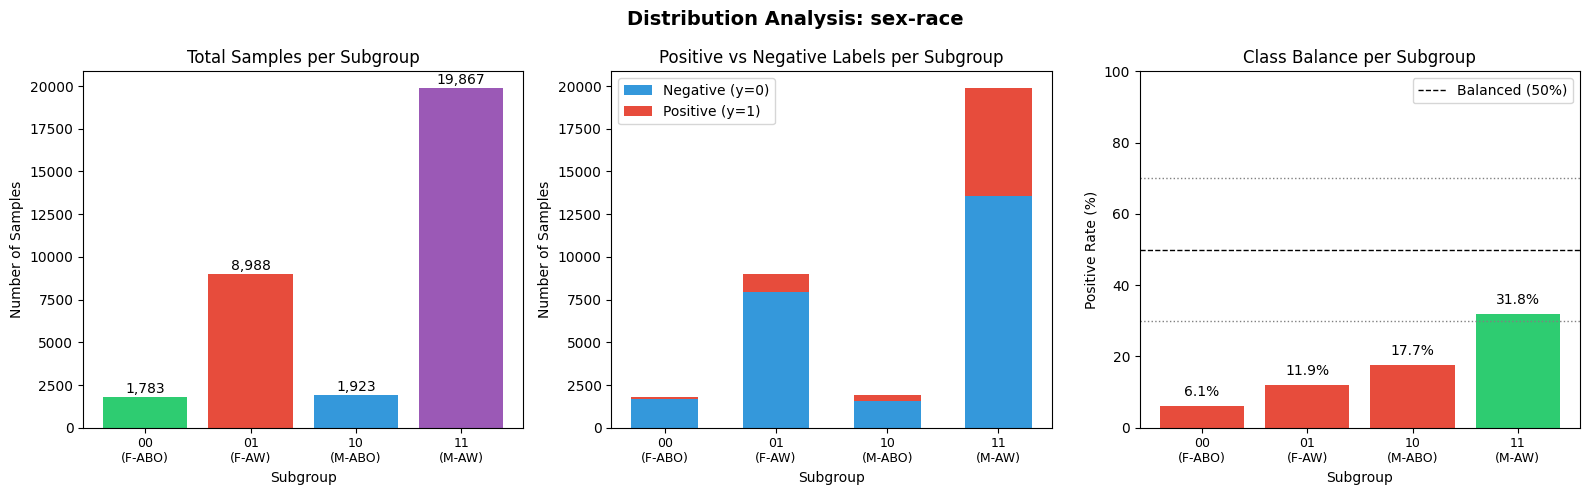

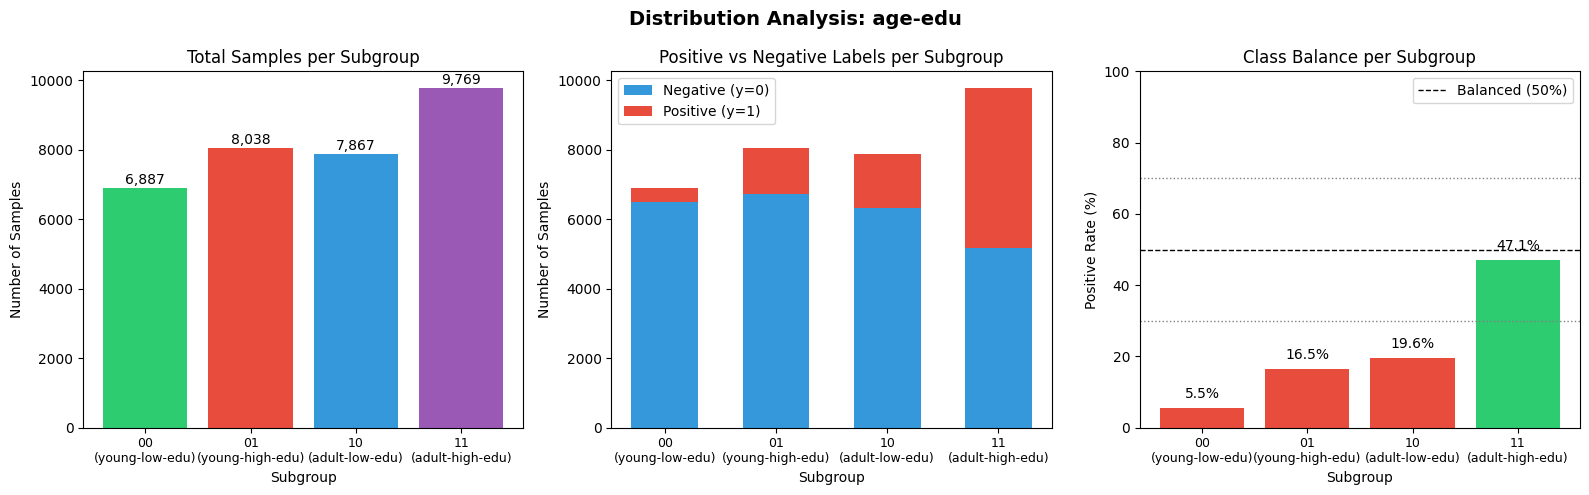

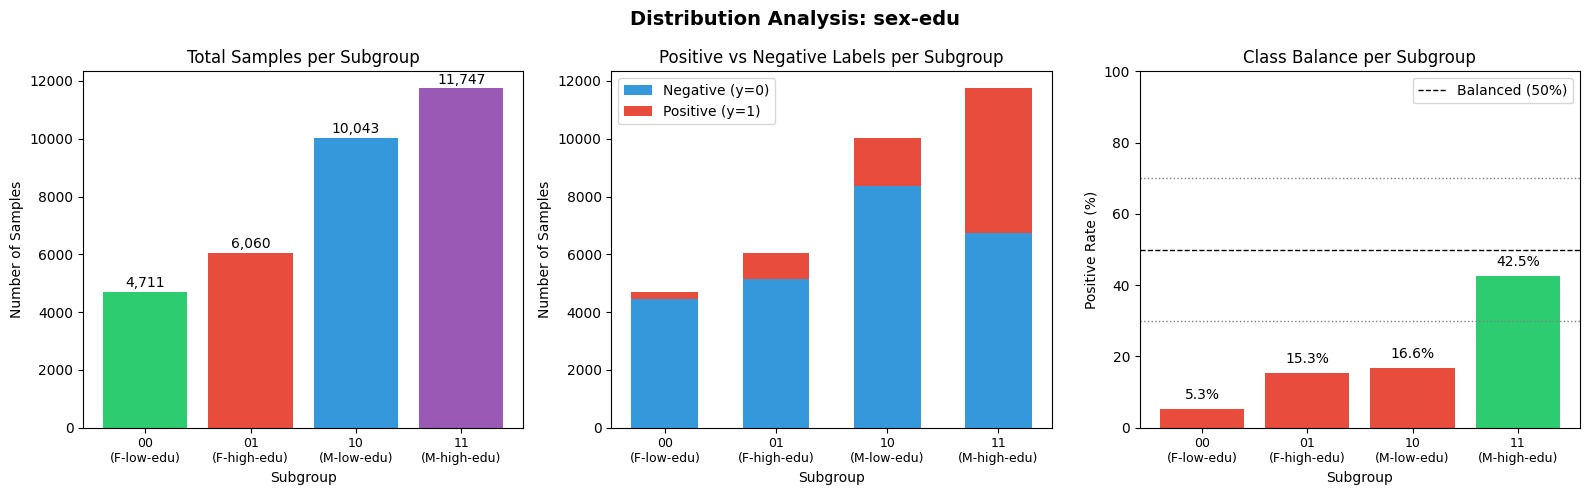

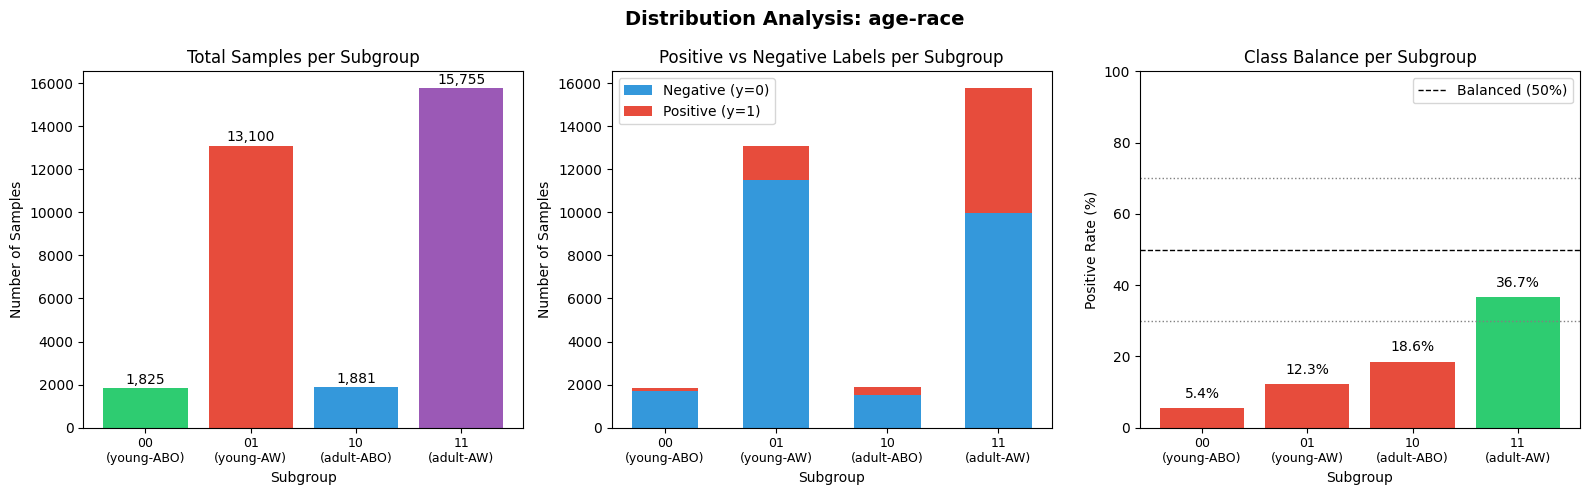

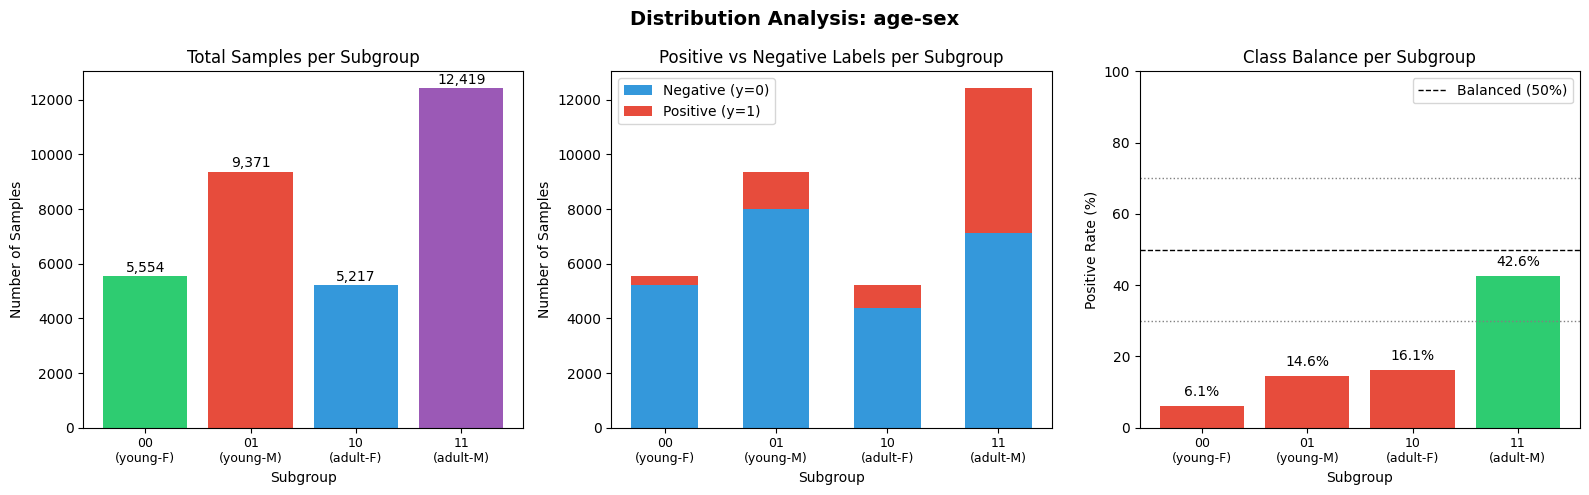

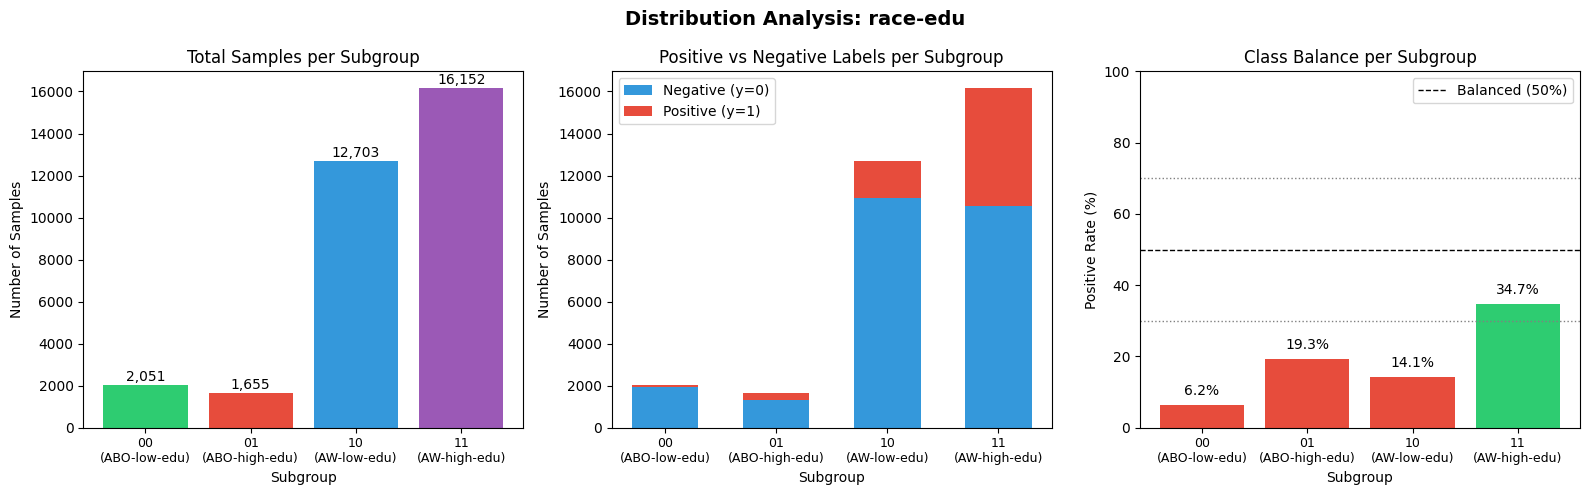

In [738]:
subgroups = ['sex-race', 'age-edu', 'sex-edu', 'age-race', 'age-sex', 'race-edu']
for subgroup in subgroups:
    df = prepare_dataframe_for_attribute(dataset_path, subgroup)
    distribution_data = get_distribution_data(df, subgroup, target_variable, mapping)
    plot_subgroup_distribution(distribution_data, subgroup)

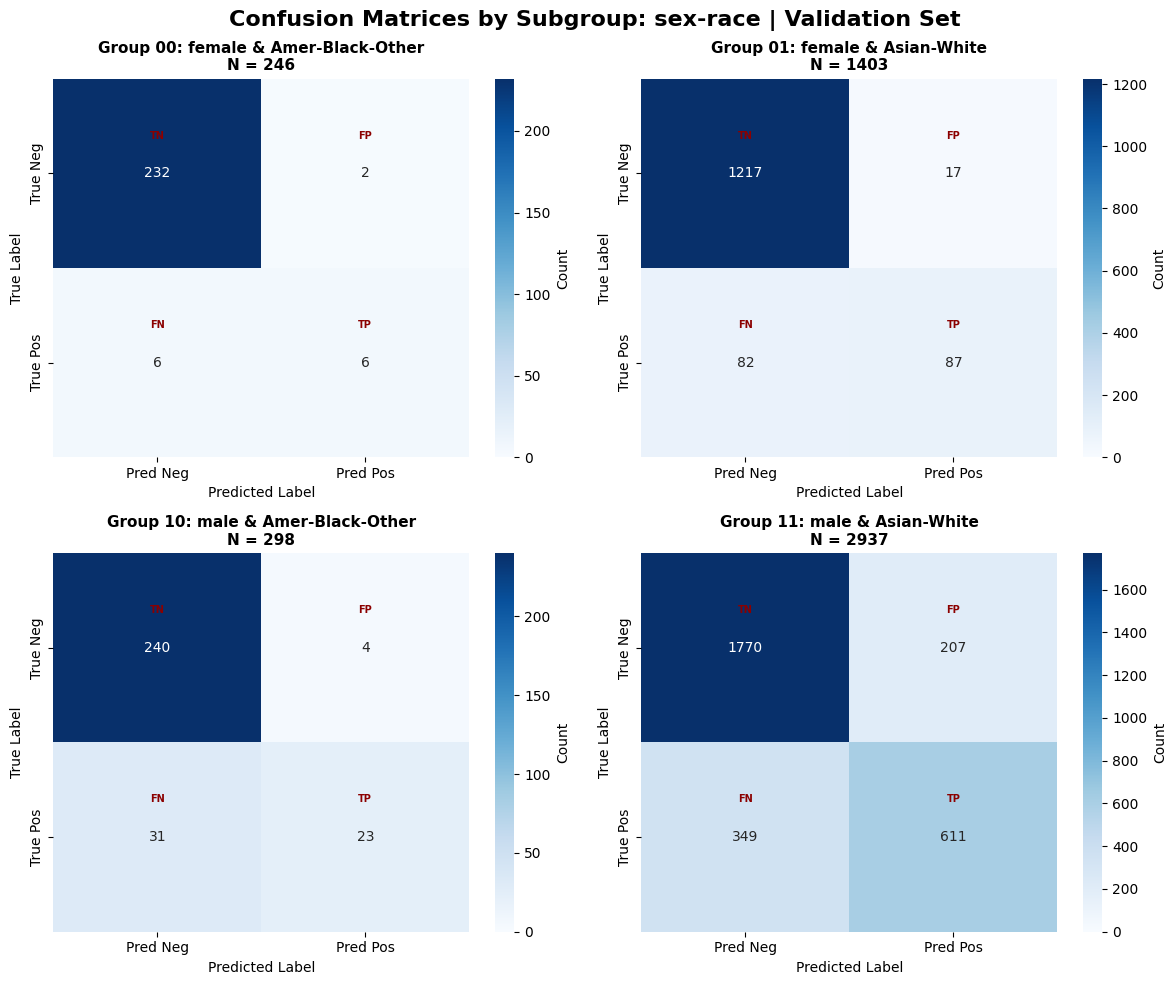

In [739]:
plot_confusion_matrix(cm_dict_val[sensible_attribute], '| Validation Set', sensible_attribute, mapping)

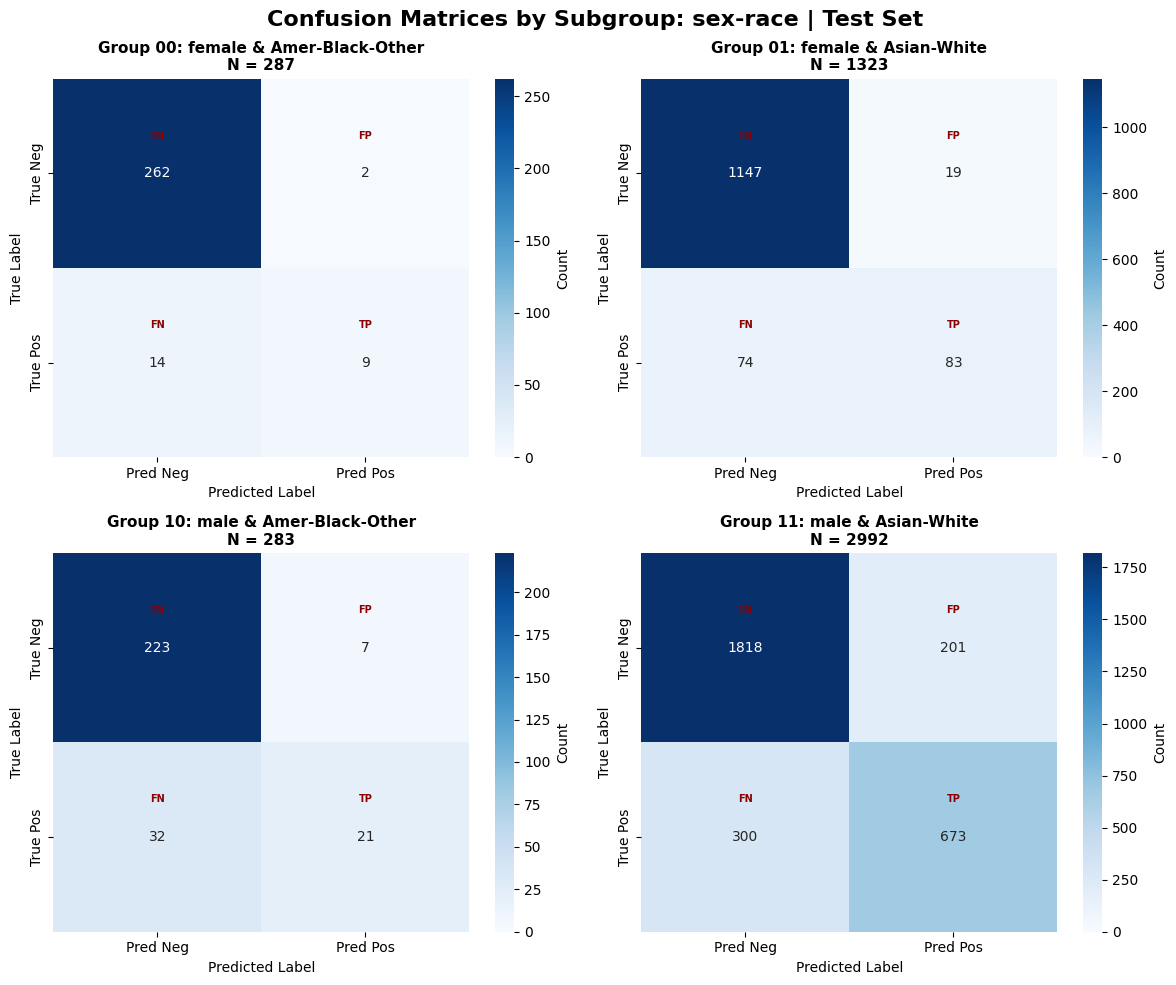

In [740]:
plot_confusion_matrix(cm_dict_test[sensible_attribute], '| Test Set', sensible_attribute, mapping)

In [741]:
weights_notsized = compute_weights_notsized(fixed_lambda, 'FPN', penalties_onval, X_train, sensible_attribute)
performance_metrics_after = performance_after_reweighting(weights_notsized, sensible_attribute, X_train, y_train, X_test, y_test)

lambda: 1.0
Training samples: 22792, Unique weights per group: {'00': 0.4910714285714285, '01': 1.3289742664742663, '10': 1.4286169970380498, '11': 0.9308877829383791}
Precision: 0.7752475247524753, Recall: 0.6492537313432836, Accuracy: 0.8669396110542477, F1: 0.7066787003610109


Observation: performance remains stable (in some cases even better). For higher lambdas (>20), the performance starts to drop. 

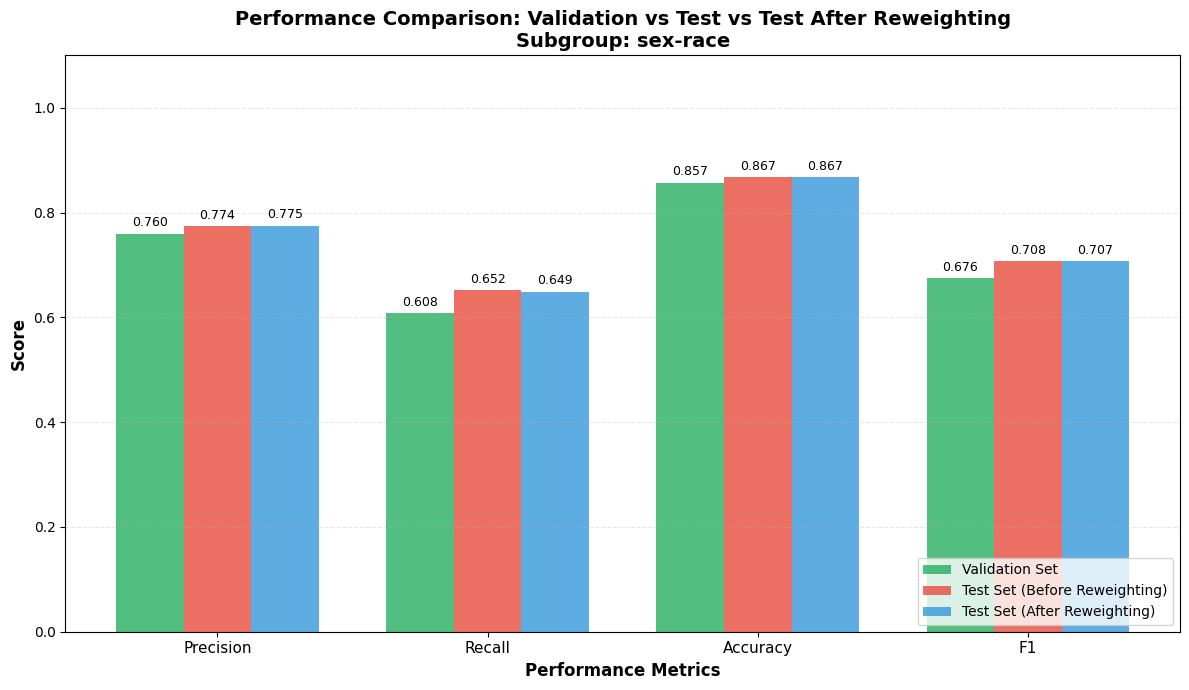


Performance Metrics Comparison:
Metric          Validation      Test (Before)   Test (After)    Δ (After-Before)
--------------------------------------------------------------------------------
Precision       0.7597          0.7744          0.7752          +0.0009
Recall          0.6084          0.6517          0.6493          -0.0025
Accuracy        0.8571          0.8671          0.8669          -0.0002
F1              0.6757          0.7078          0.7067          -0.0011


In [742]:
# Plot performance comparison
plot_performance_comparison(performance_metrics_val, performance_metrics_test, performance_metrics_after, sensible_attribute)

---

# Penalty After Reweighting Plots

## Penalty before and after reweighting - all FMs

In [660]:
fixed_lambda = 1.0

FAIRNESS METRIC: FPN
lambda: 1.0
Training samples: 22792, Unique weights per group: {'00': 1.1112903225806452, '01': 1.6837349397590362, '10': 1.072973578145992, '11': 0.7914111650872023}
{np.int64(1): array([[1473,  222],
       [ 246,  692]]), np.int64(0): array([[1976,    8],
       [ 174,   94]])}
{np.int64(0): array([[1408,   22],
       [  91,   89]]), np.int64(1): array([[2041,  208],
       [ 329,  697]])}
{'10': array([[612,  18],
       [ 52,  70]]), '00': array([[797,   3],
       [ 36,  22]]), '11': array([[860, 205],
       [192, 624]]), '01': array([[1180,    4],
       [ 135,   75]])}
FAIRNESS METRIC: PPE
lambda: 1.0
Training samples: 22792, Unique weights per group: {'00': 1.6537776412776415, '01': 1.563616035390229, '10': 0.8255984393124538, '11': 0.24178978752399094}
{np.int64(1): array([[1470,  225],
       [ 248,  690]]), np.int64(0): array([[1976,    8],
       [ 173,   95]])}
{np.int64(0): array([[1408,   22],
       [  90,   90]]), np.int64(1): array([[2038,  211

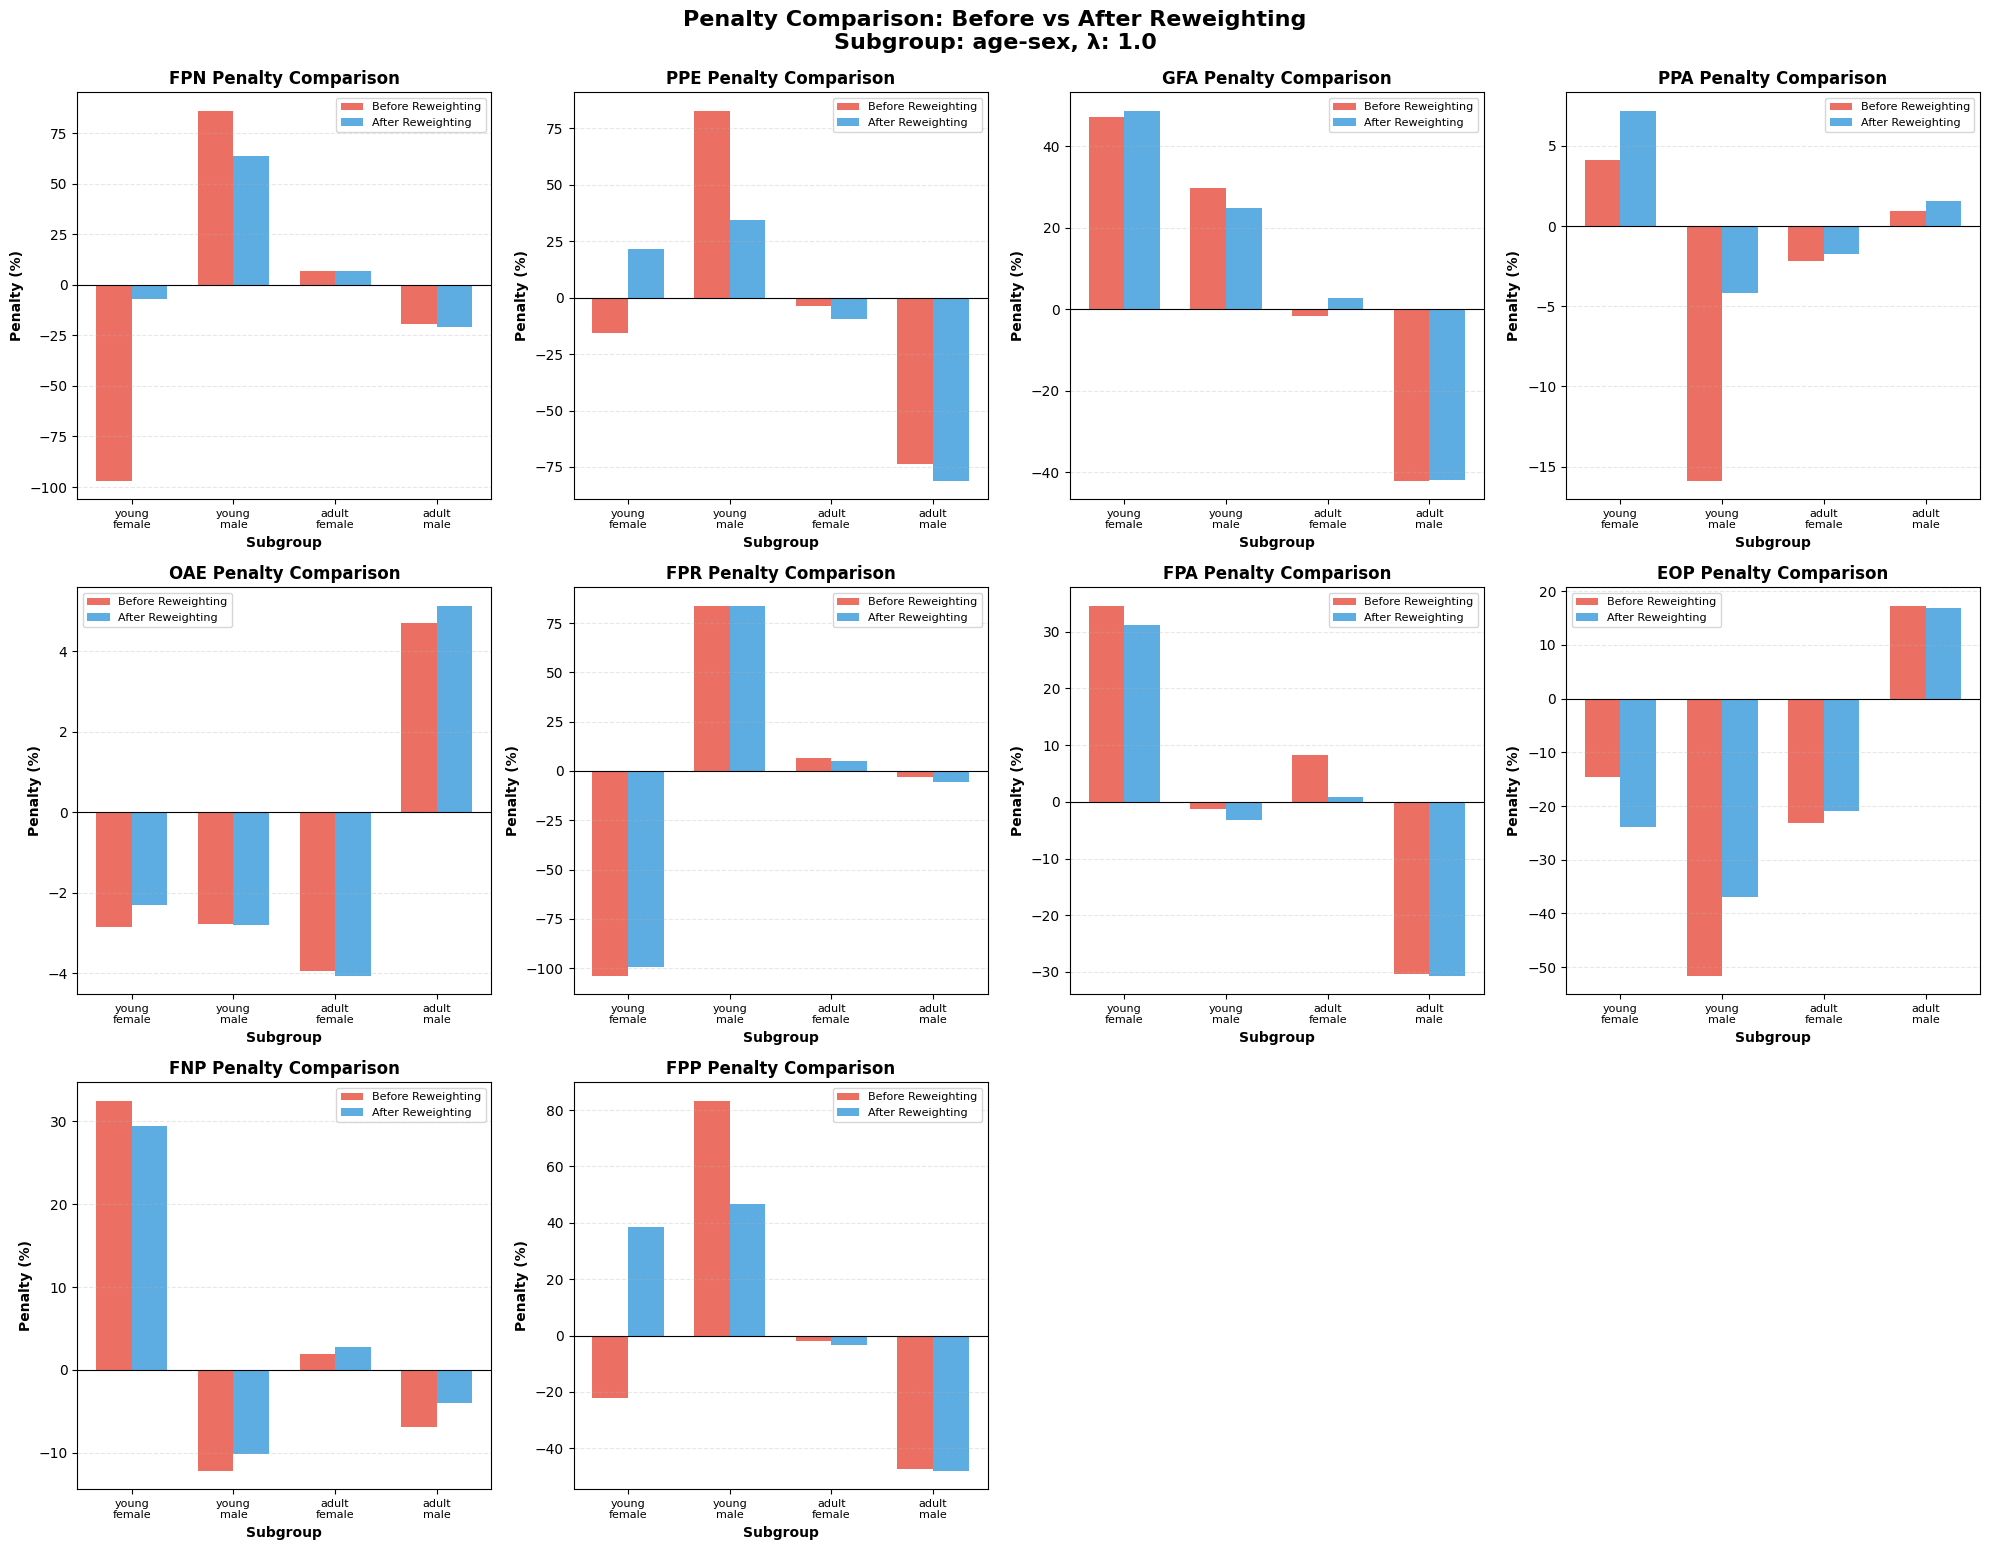

In [661]:
# Use as many fairness metrics as needed
cm_dict_reweighted = {}
penalties_ontest_after_reweighting = {}

for metric in fair_metrics:
    print("FAIRNESS METRIC:", metric)
    weights_notsized = compute_weights_notsized(fixed_lambda, metric, penalties_onval, X_train, sensible_attribute)
    penalties_ontest_after_reweighting[metric] = compute_penalties_after_reweighting(weights_notsized, metric, dataset_path, sensible_attribute, X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels) # Get only harmonic penalty
    # print("\n")

plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, 
                                        sensible_attribute, mapping, fixed_lambda)

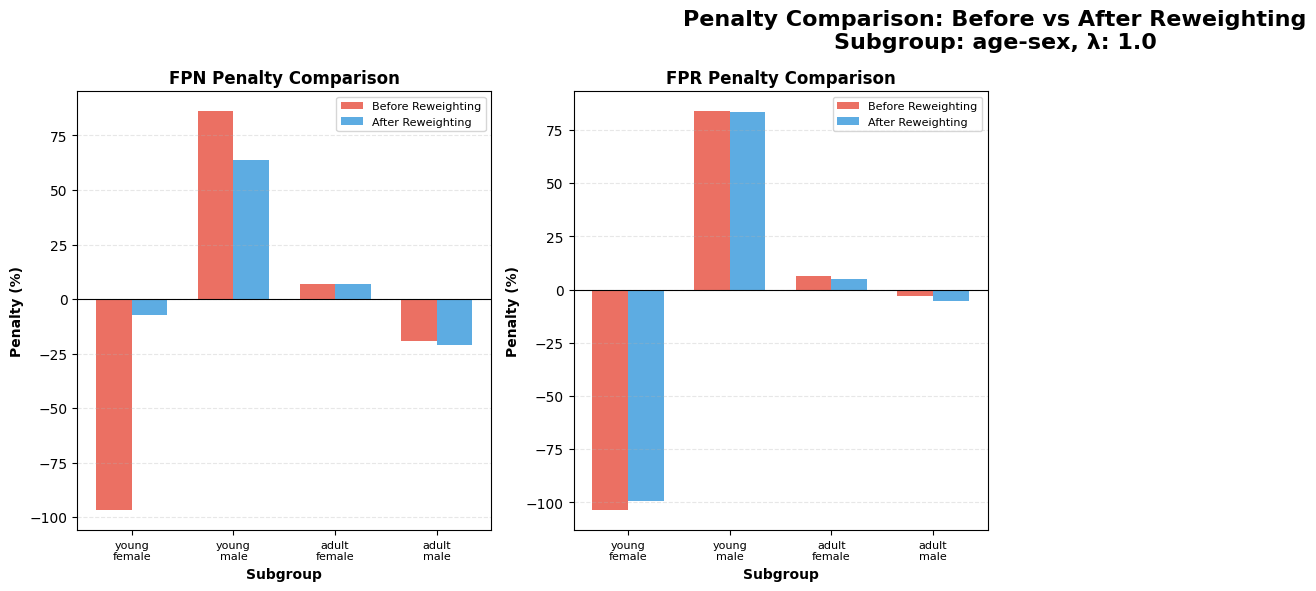

In [662]:
# Use as many fairness metrics as needed
metrics=['FPN', 'FPR']
plot_penalty_comparison_all_generalized(metrics, penalties_ontest, penalties_ontest_after_reweighting, 
                                        sensible_attribute, mapping, fixed_lambda)

In [663]:
if ALL_FM_L_NOTSIZED == 1:
    for l in lambdas:
        for metric in fair_metrics:
            # print("FAIRNESS METRIC:", metric)
            weights_notsized = compute_weights_notsized(l, metric, penalties_onval, X_train, sensible_attribute)
            penalties_ontest_after_reweighting[metric]= compute_penalties_after_reweighting(weights_notsized, metric, dataset_path, sensible_attribute, X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels) # Get only harmonic penalty
            # print("\n")

        plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, 
                                                    sensible_attribute, mapping, l)

In [664]:
if SIZED == 1 and ALL_FM_L_SIZED == 1:
    for l in lambdas:
        for metric in fair_metrics:
            # print("FAIRNESS METRIC:", metric)
            weights_sized = compute_weights_sized(l, metric, penalties_onval, X_train, sensible_attribute)
            penalties_ontest_after_reweighting[metric]= compute_penalties_after_reweighting(weights_sized, metric, dataset_path, sensible_attribute, X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels) # Get only harmonic penalty
            # print("\n")

        plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, 
                                                sensible_attribute, mapping, l)

## Penalty before and after reweighting 
* for all lambdas
* single plot
* NOT SIZED WEIGHTS

lambda: 0.5
Training samples: 22792, Unique weights per group: {'00': 1.0556451612903226, '01': 1.341867469879518, '10': 1.0364867890729959, '11': 0.8957055825436011}
{np.int64(1): array([[1475,  220],
       [ 245,  693]]), np.int64(0): array([[1965,   19],
       [ 166,  102]])}
{np.int64(0): array([[1397,   33],
       [  84,   96]]), np.int64(1): array([[2043,  206],
       [ 327,  699]])}
{'10': array([[612,  18],
       [ 52,  70]]), '00': array([[796,   4],
       [ 36,  22]]), '11': array([[862, 203],
       [194, 622]]), '01': array([[1180,    4],
       [ 135,   75]])}
lambda: 1.0
Training samples: 22792, Unique weights per group: {'00': 1.1112903225806452, '01': 1.6837349397590362, '10': 1.072973578145992, '11': 0.7914111650872023}
{np.int64(1): array([[1473,  222],
       [ 246,  692]]), np.int64(0): array([[1976,    8],
       [ 174,   94]])}
{np.int64(0): array([[1408,   22],
       [  91,   89]]), np.int64(1): array([[2041,  208],
       [ 329,  697]])}
{'10': array([[61

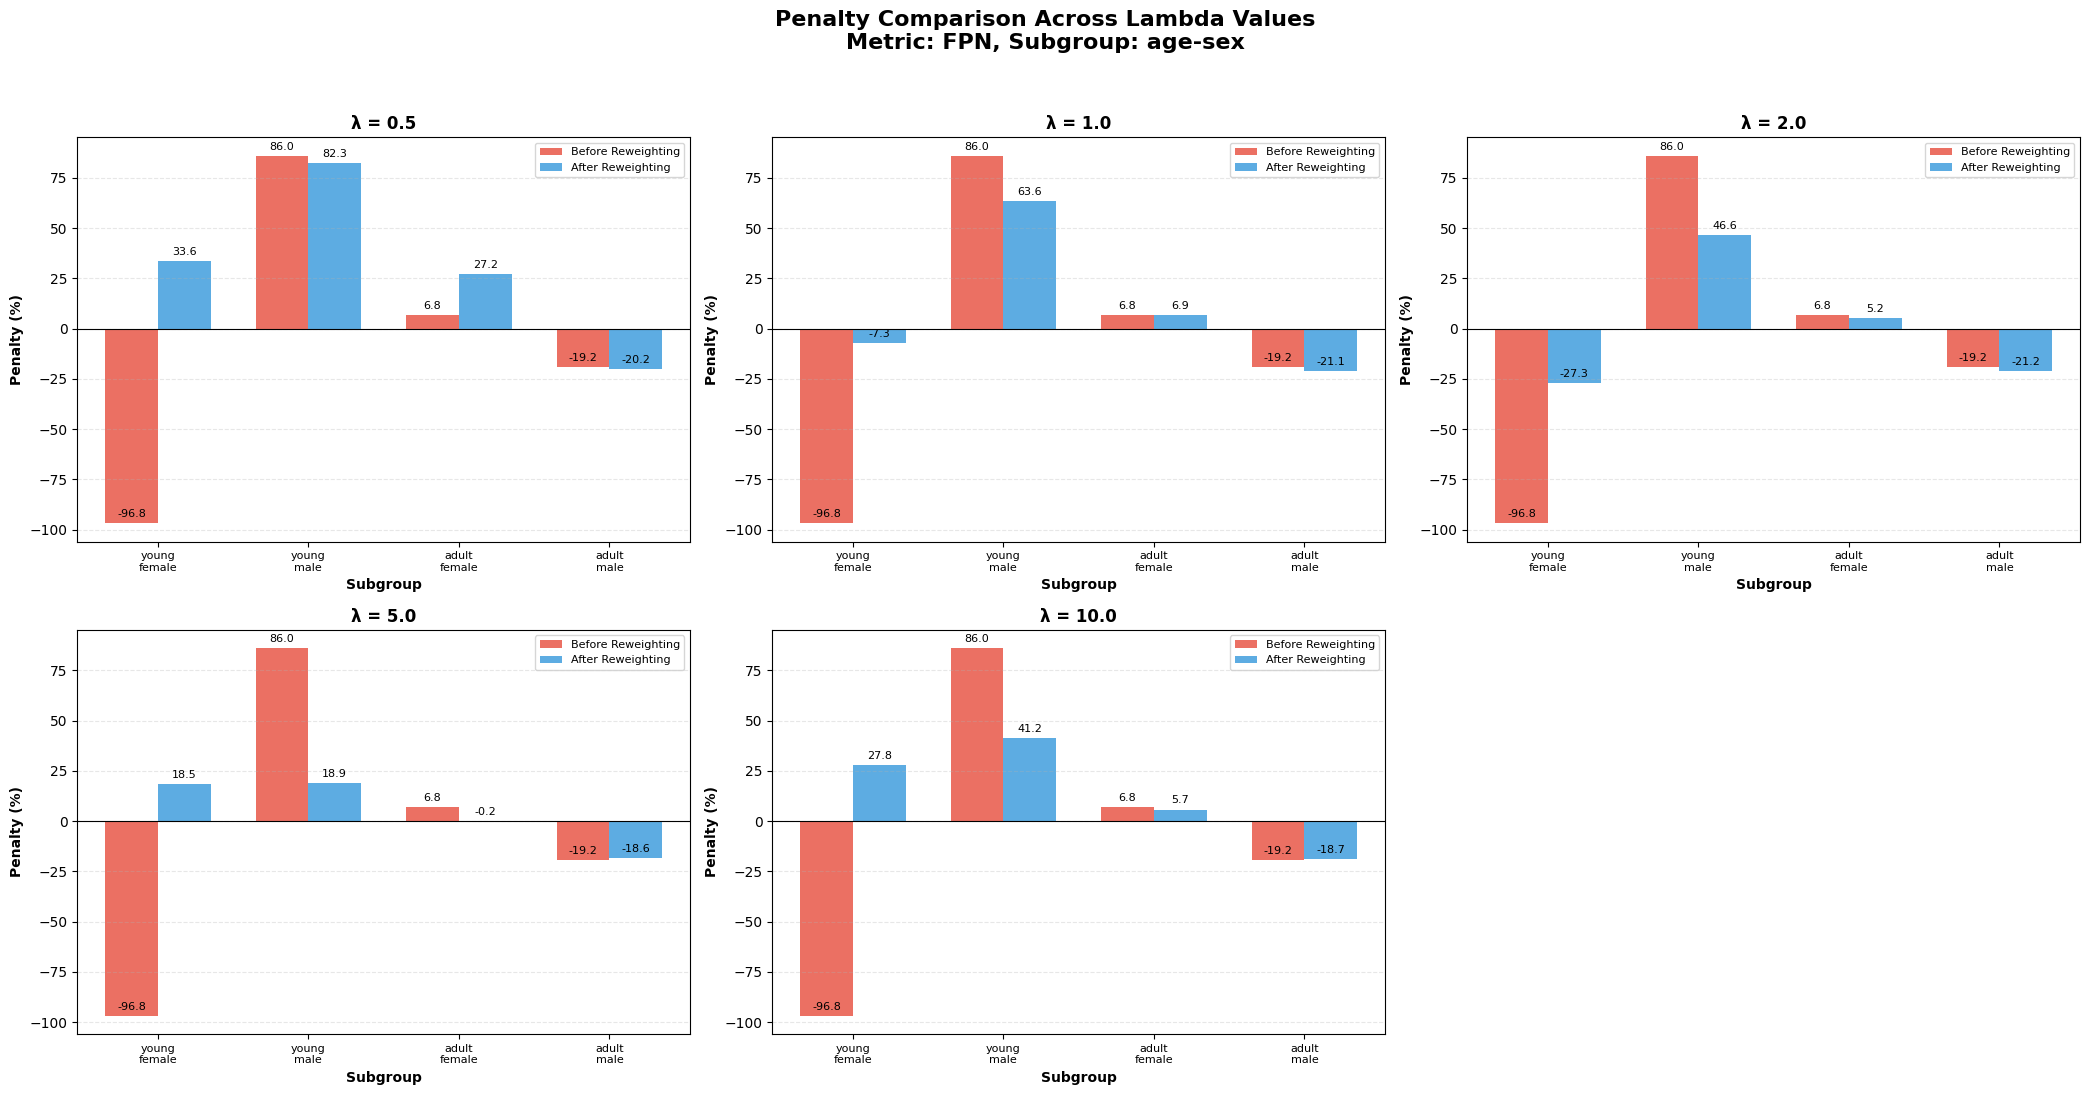

In [665]:
# First, compute penalties for each lambda
penalties_after_by_lambda = {}
lambdas = [0.5, 1.0, 2.0, 5.0, 10.0]
metric = 'FPN'

for lambd in lambdas:
    penalties_ontest_after_reweighting = {}
    weights_notsized = compute_weights_notsized(lambd, metric, penalties_onval, X_train, sensible_attribute)
    penalties_ontest_after_reweighting[metric] = compute_penalties_after_reweighting(
        weights_notsized, metric, dataset_path, sensible_attribute, 
        X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels
    )
    penalties_after_by_lambda[lambd] = penalties_ontest_after_reweighting

# Then plot
plot_penalty_comparison_lambdas(metric, lambdas, penalties_ontest, penalties_after_by_lambda, 
                                sensible_attribute, mapping)

## Penalty before and after reweighting 
* for all lambdas
* single plot
* SIZED WEIGHTS

Training samples: 22792, Unique weights per group: {'00': 1.0245695084927782, '01': 1.2598759859157862, '10': 1.015463068425245, '11': 0.8957055825436011}
{np.int64(1): array([[1473,  222],
       [ 244,  694]]), np.int64(0): array([[1977,    7],
       [ 174,   94]])}
{np.int64(0): array([[1408,   22],
       [  90,   90]]), np.int64(1): array([[2042,  207],
       [ 328,  698]])}
{'10': array([[612,  18],
       [ 52,  70]]), '00': array([[796,   4],
       [ 39,  19]]), '11': array([[865, 200],
       [196, 620]]), '01': array([[1179,    5],
       [ 135,   75]])}
Training samples: 22792, Unique weights per group: {'00': 1.0491390169855561, '01': 1.5197519718315724, '10': 1.03092613685049, '11': 0.7914111650872023}
{np.int64(1): array([[1474,  221],
       [ 246,  692]]), np.int64(0): array([[1964,   20],
       [ 168,  100]])}
{np.int64(0): array([[1397,   33],
       [  84,   96]]), np.int64(1): array([[2041,  208],
       [ 330,  696]])}
{'10': array([[612,  18],
       [ 52,  70

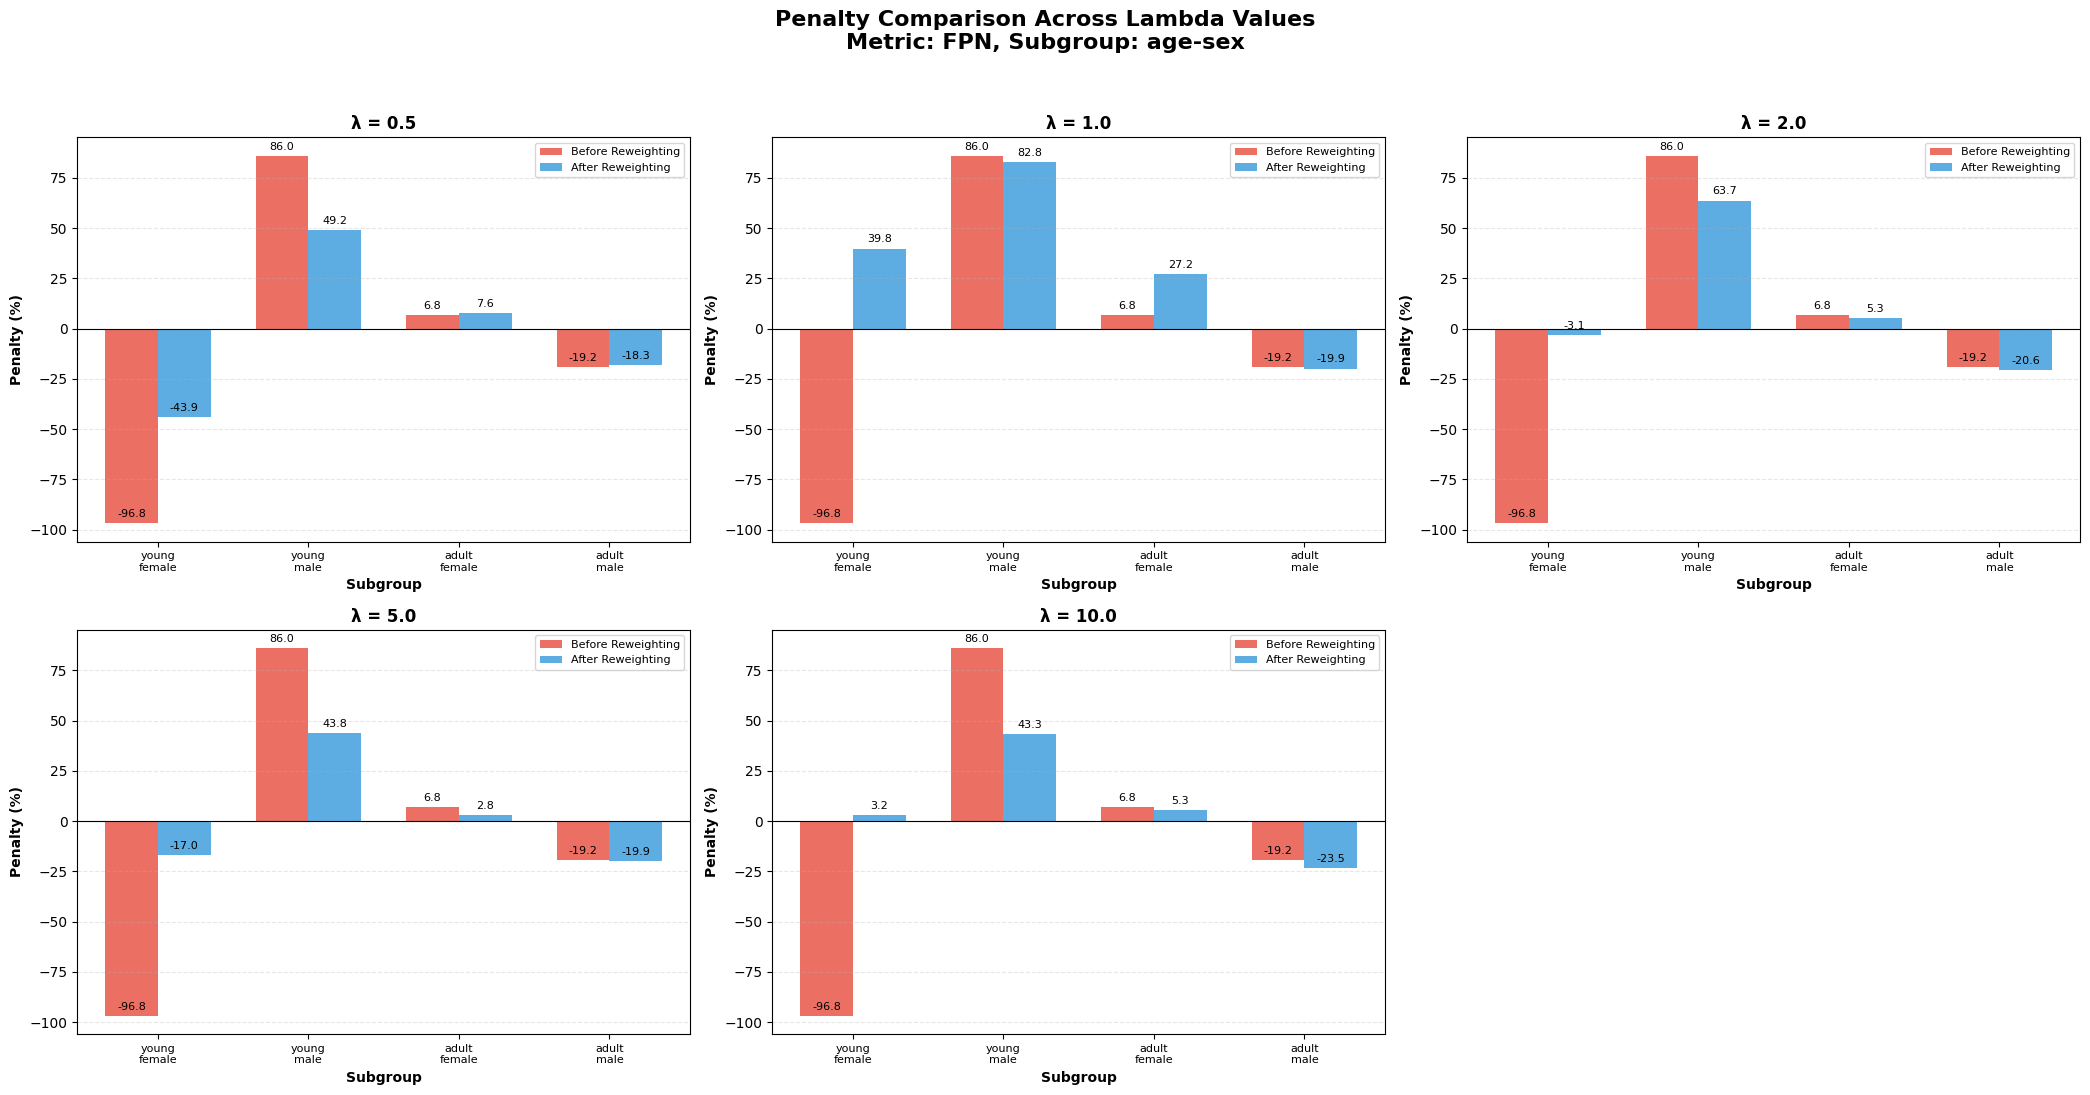

In [666]:
# First, compute penalties for each lambda
penalties_after_by_lambda = {}
lambdas = [0.5, 1.0, 2.0, 5.0, 10.0]
metric = 'FPN'

for lambd in lambdas:
    penalties_ontest_after_reweighting = {}
    weights_notsized = compute_weights_sized(lambd, metric, penalties_onval, X_train, sensible_attribute)
    penalties_ontest_after_reweighting[metric] = compute_penalties_after_reweighting(
        weights_notsized, metric, dataset_path, sensible_attribute, 
        X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels
    )
    penalties_after_by_lambda[lambd] = penalties_ontest_after_reweighting

# Then plot
plot_penalty_comparison_lambdas(metric, lambdas, penalties_ontest, penalties_after_by_lambda, 
                                sensible_attribute, mapping)

# KFOLD

## Utils

In [667]:
# Run K-fold penalty computation
penalties_kfold_avg, penalties_per_fold = compute_penalties_kfold(sensible_attribute, fair_metrics, n_folds=5)

K-FOLD CROSS-VALIDATION FOR PENALTY ESTIMATION (K=5)
Train+Val samples: 27676
Test samples (held out): 4885

--- Fold 1/5 ---
  Val distribution: {'00': 982, '01': 1577, '10': 913, '11': 2064}

--- Fold 2/5 ---
  Val distribution: {'00': 911, '01': 1630, '10': 867, '11': 2127}

--- Fold 3/5 ---
  Val distribution: {'00': 936, '01': 1606, '10': 926, '11': 2067}

--- Fold 4/5 ---
  Val distribution: {'00': 939, '01': 1552, '10': 871, '11': 2173}

--- Fold 5/5 ---
  Val distribution: {'00': 928, '01': 1612, '10': 888, '11': 2107}

AVERAGED PENALTIES (across 5 folds)

FPN:
  00: avg=-29.44%, std=77.25, folds=['61.5', '-56.6', '30.9', '-160.4', '-22.6']
  01: avg=+48.58%, std=19.60, folds=['25.2', '59.5', '25.9', '73.9', '58.4']
  10: avg=+7.25%, std=12.56, folds=['-4.0', '16.7', '-1.9', '27.3', '-1.9']
  11: avg=-16.10%, std=3.77, folds=['-13.4', '-16.4', '-10.5', '-19.9', '-20.3']

PPE:
  00: avg=+35.50%, std=32.33, folds=['79.7', '2.7', '65.8', '0.3', '29.0']
  01: avg=+41.62%, std=19.93

In [668]:
# Compute penalties on test set after K-fold reweighting
penalties_ontest_after_kfold = {}
for metric in fair_metrics:
    weights_kfold, X_trainval, y_trainval = compute_weights_kfold(5.0, metric)
    penalties_ontest_after_kfold[metric] = compute_penalties_after_reweighting_kfold(weights_kfold, X_trainval, y_trainval, metric, dataset_path, sensible_attribute, X_test, y_test, fair_metrics, mapping, target_variable_labels)
    penalties_after_by_lambda[lambd] = penalties_ontest_after_reweighting
    
print("\nPenalties after K-fold reweighting computed for all metrics.")

Training samples: 27676, Weights per group (K-fold): {'00': 0.01, '01': np.float64(3.4289487302977824), '10': np.float64(1.3623778404094886), '11': np.float64(0.1950641553259187)}
Training samples: 27676, Weights per group (K-fold): {'00': np.float64(2.7750799013318237), '01': np.float64(3.0809910200620676), '10': np.float64(1.041378358182562), '11': 0.01}
Training samples: 27676, Weights per group (K-fold): {'00': np.float64(3.420921535171719), '01': np.float64(2.4634514447642175), '10': np.float64(0.9464884304331825), '11': 0.01}
Training samples: 27676, Weights per group (K-fold): {'00': np.float64(1.1731102931558062), '01': np.float64(0.5558088407817294), '10': np.float64(0.8352268914963762), '11': np.float64(1.048819646117961)}
Training samples: 27676, Weights per group (K-fold): {'00': np.float64(0.821525470071448), '01': np.float64(0.8359071633230097), '10': np.float64(0.7494272547431415), '11': np.float64(1.3102612556516333)}
Training samples: 27676, Weights per group (K-fold):

## KFOLD: For each lambda
* Weights not sized

Training samples: 27676, Weights per group (K-fold): {'00': np.float64(0.8527829483540788), '01': np.float64(1.2428948730297782), '10': np.float64(1.036237784040949), '11': np.float64(0.9195064155325918)}
Training samples: 27676, Weights per group (K-fold): {'00': np.float64(0.7055658967081575), '01': np.float64(1.4857897460595564), '10': np.float64(1.0724755680818978), '11': np.float64(0.8390128310651838)}
Training samples: 27676, Weights per group (K-fold): {'00': np.float64(0.4111317934163149), '01': np.float64(1.971579492119113), '10': np.float64(1.1449511361637954), '11': np.float64(0.6780256621303675)}
Training samples: 27676, Weights per group (K-fold): {'00': 0.01, '01': np.float64(3.4289487302977824), '10': np.float64(1.3623778404094886), '11': np.float64(0.1950641553259187)}
Training samples: 27676, Weights per group (K-fold): {'00': 0.01, '01': np.float64(5.857897460595565), '10': np.float64(1.724755680818977), '11': 0.01}


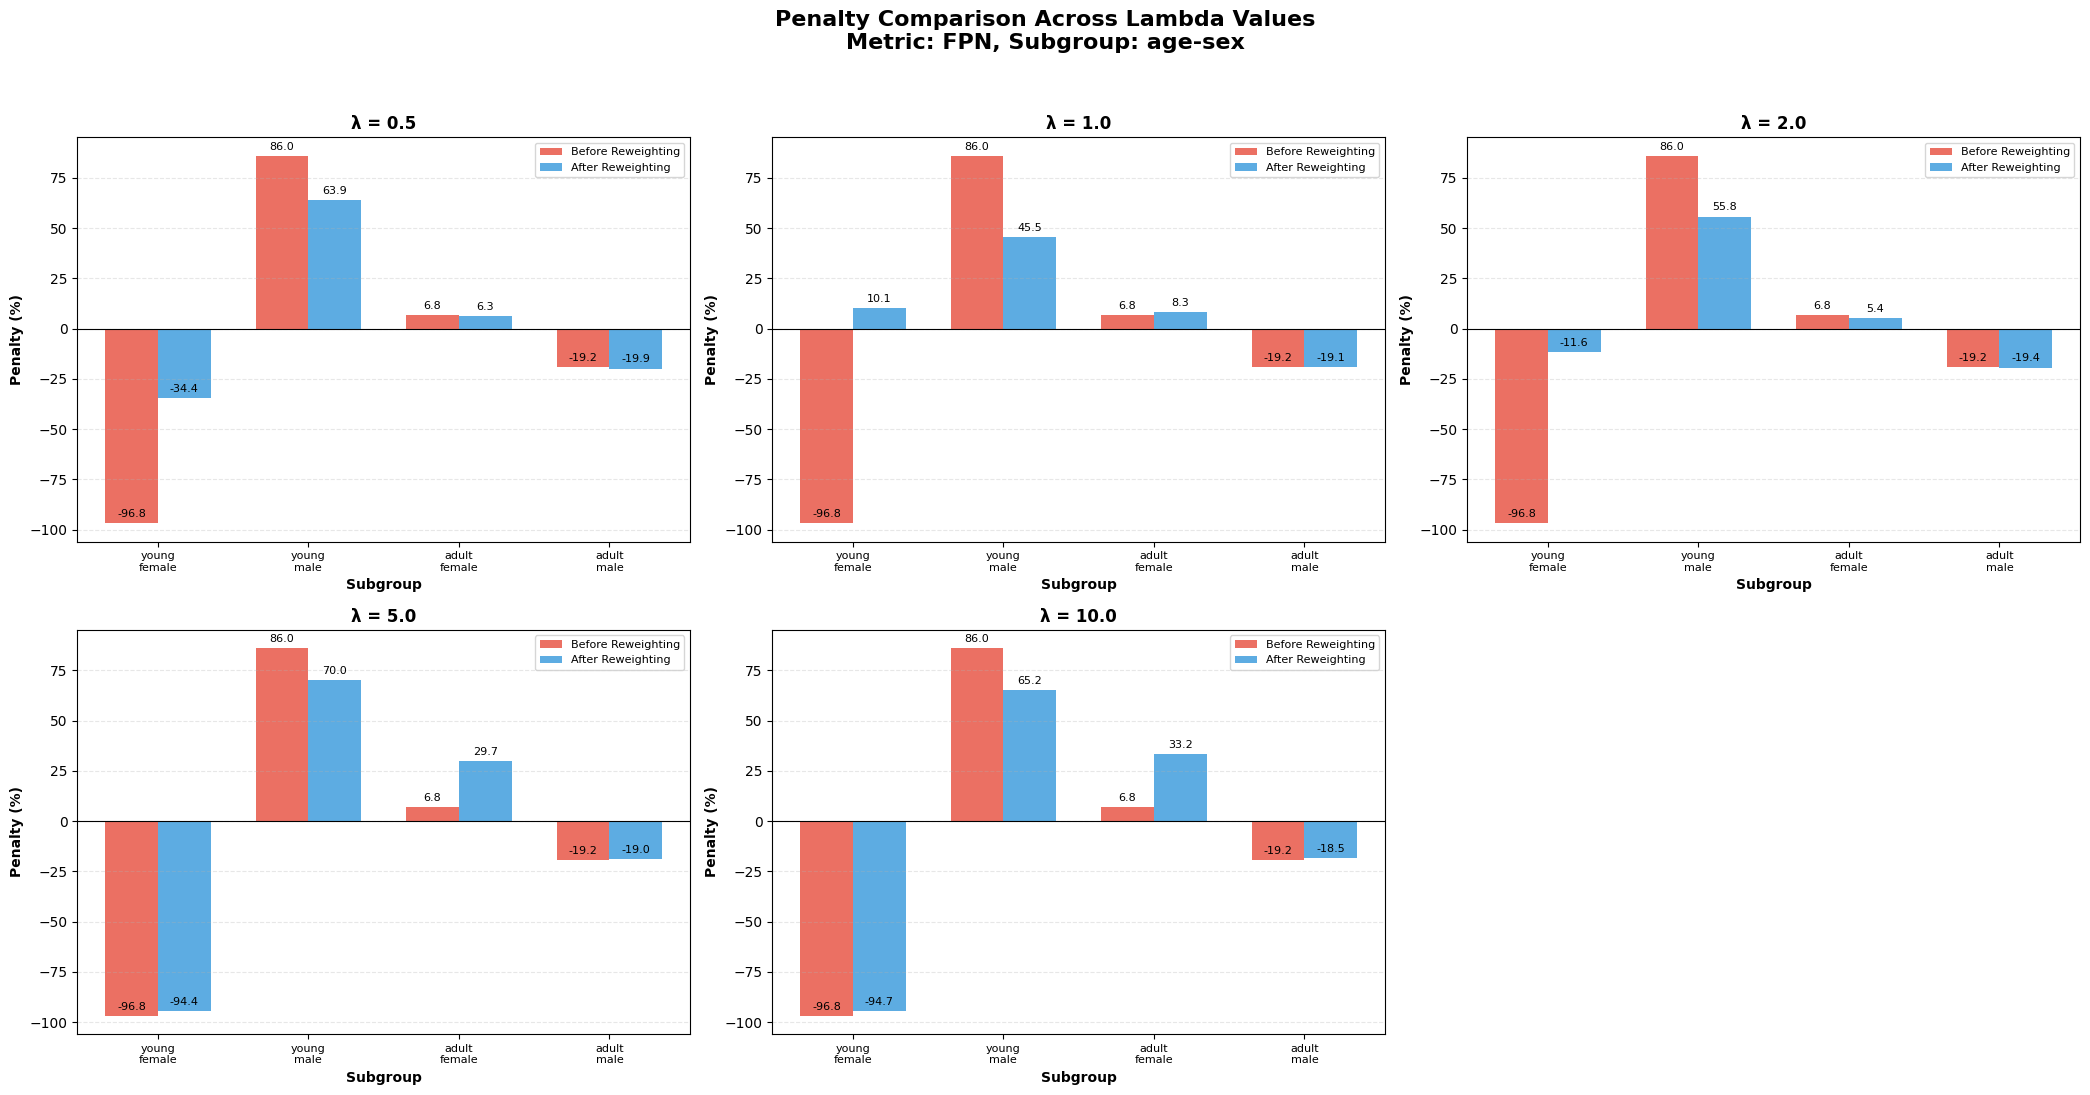

In [669]:
# First, compute penalties for each lambda
penalties_after_by_lambda_kfold = {}
metric = 'FPN'

for l in lambdas: 
    penalties_ontest_after_reweighting = {}
    weights_kfold, X_trainval, y_trainval = compute_weights_kfold(l, metric)
    penalties_ontest_after_reweighting[metric] = compute_penalties_after_reweighting_kfold(weights_kfold, X_trainval, y_trainval, metric  , dataset_path, sensible_attribute, X_test, y_test, fair_metrics, mapping, target_variable_labels)
    penalties_after_by_lambda_kfold[l] = penalties_ontest_after_reweighting

# Then plot
plot_penalty_comparison_lambdas(metric, lambdas, penalties_ontest, penalties_after_by_lambda_kfold, 
                            sensible_attribute, mapping)

## KFOLD: For each lambda
* Weights SIZED

Training samples: 22792, Unique weights per group: {'00': 1.0245695084927782, '01': 1.2598759859157862, '10': 1.015463068425245, '11': 0.8957055825436011}
{np.int64(1): array([[1473,  222],
       [ 244,  694]]), np.int64(0): array([[1977,    7],
       [ 174,   94]])}
{np.int64(0): array([[1408,   22],
       [  90,   90]]), np.int64(1): array([[2042,  207],
       [ 328,  698]])}
{'10': array([[612,  18],
       [ 52,  70]]), '00': array([[796,   4],
       [ 39,  19]]), '11': array([[865, 200],
       [196, 620]]), '01': array([[1179,    5],
       [ 135,   75]])}
Training samples: 22792, Unique weights per group: {'00': 1.0491390169855561, '01': 1.5197519718315724, '10': 1.03092613685049, '11': 0.7914111650872023}
{np.int64(1): array([[1474,  221],
       [ 246,  692]]), np.int64(0): array([[1964,   20],
       [ 168,  100]])}
{np.int64(0): array([[1397,   33],
       [  84,   96]]), np.int64(1): array([[2041,  208],
       [ 330,  696]])}
{'10': array([[612,  18],
       [ 52,  70

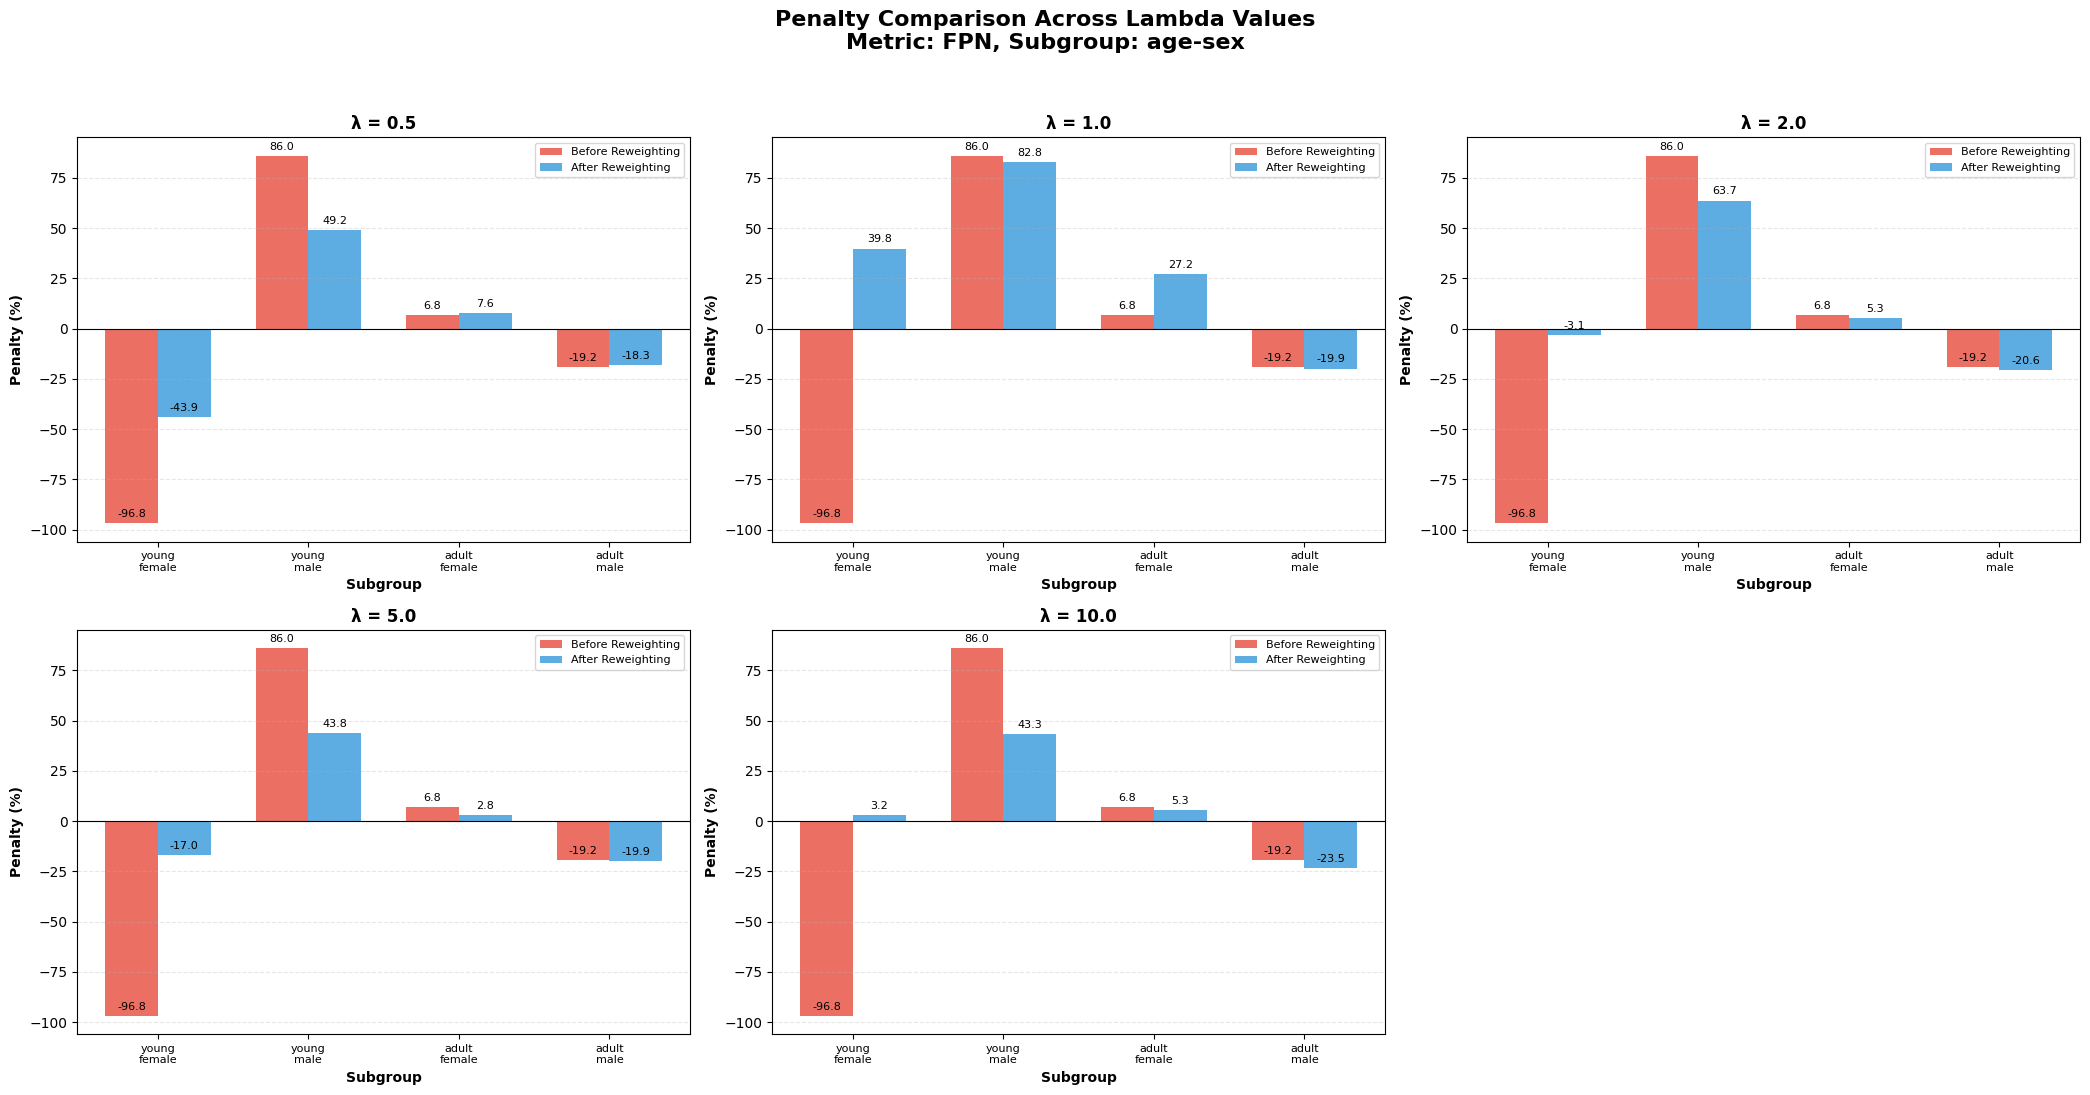

In [670]:
# First, compute penalties for each lambda
penalties_after_by_lambda = {}
lambdas = [0.5, 1.0, 2.0, 5.0, 10.0]
metric = 'FPN'

for lambd in lambdas:
    penalties_ontest_after_reweighting = {}
    weights_notsized = compute_weights_sized(lambd, metric, penalties_onval, X_train, sensible_attribute)
    penalties_ontest_after_reweighting[metric] = compute_penalties_after_reweighting(
        weights_notsized, metric, dataset_path, sensible_attribute, 
        X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels
    )
    penalties_after_by_lambda[lambd] = penalties_ontest_after_reweighting

# Then plot
plot_penalty_comparison_lambdas(metric, lambdas, penalties_ontest, penalties_after_by_lambda, 
                                sensible_attribute, mapping)

## Penalty before and after reweighting 
* fixed FM and lambda
* Parameters chosen by user for general tests

lambda: 1.0
Training samples: 22792, Unique weights per group: {'00': 1.1112903225806452, '01': 1.6837349397590362, '10': 1.072973578145992, '11': 0.7914111650872023}
{np.int64(1): array([[1473,  222],
       [ 246,  692]]), np.int64(0): array([[1976,    8],
       [ 174,   94]])}
{np.int64(0): array([[1408,   22],
       [  91,   89]]), np.int64(1): array([[2041,  208],
       [ 329,  697]])}
{'10': array([[612,  18],
       [ 52,  70]]), '00': array([[797,   3],
       [ 36,  22]]), '11': array([[860, 205],
       [192, 624]]), '01': array([[1180,    4],
       [ 135,   75]])}


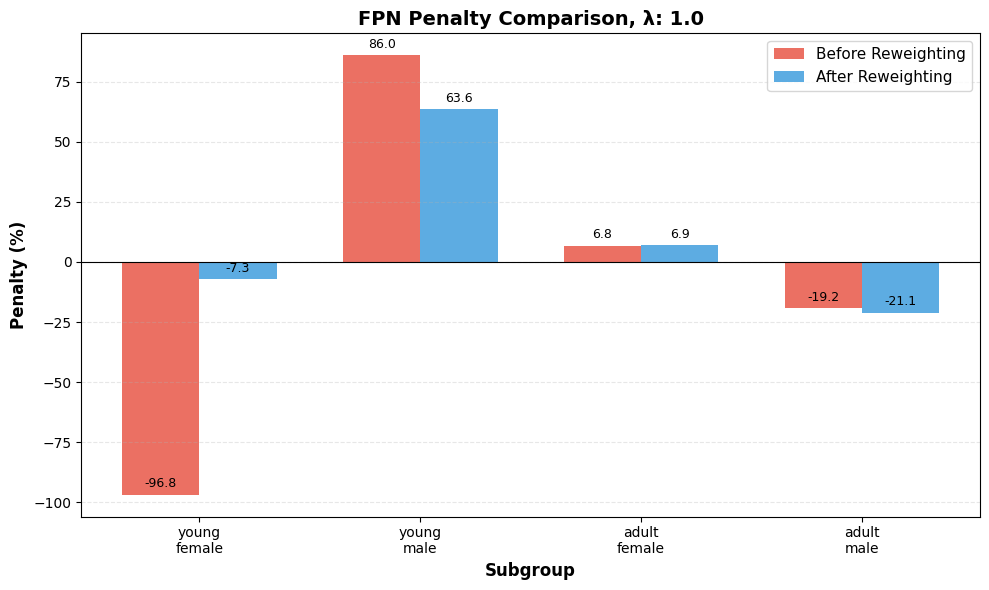


FPN - Penalty Changes:
  young-female: -96.84 → -7.26 (Δ = +89.58)
  young-male: 86.04 → 63.55 (Δ = -22.48)
  adult-female: 6.80 → 6.86 (Δ = +0.06)
  adult-male: -19.20 → -21.09 (Δ = -1.88)
------------------------------------------------------------


In [671]:
metrics = ['FPN']
for metric in metrics:
    weights_notsized = compute_weights_notsized(fixed_lambda, metric, penalties_onval, X_train, sensible_attribute)
    penalties_ontest_after_reweighting[metric]= compute_penalties_after_reweighting(weights_notsized, metric, dataset_path, sensible_attribute, X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels) # Get only harmonic penalty

plot_penalty_comparison_all_individual(metrics, penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping, fixed_lambda)

## Penalty before and after reweighting
* All lambdas
* Individual plots

lambda: 0.5
Training samples: 22792, Unique weights per group: {'00': 1.0556451612903226, '01': 1.341867469879518, '10': 1.0364867890729959, '11': 0.8957055825436011}
{np.int64(1): array([[1475,  220],
       [ 245,  693]]), np.int64(0): array([[1965,   19],
       [ 166,  102]])}
{np.int64(0): array([[1397,   33],
       [  84,   96]]), np.int64(1): array([[2043,  206],
       [ 327,  699]])}
{'10': array([[612,  18],
       [ 52,  70]]), '00': array([[796,   4],
       [ 36,  22]]), '11': array([[862, 203],
       [194, 622]]), '01': array([[1180,    4],
       [ 135,   75]])}


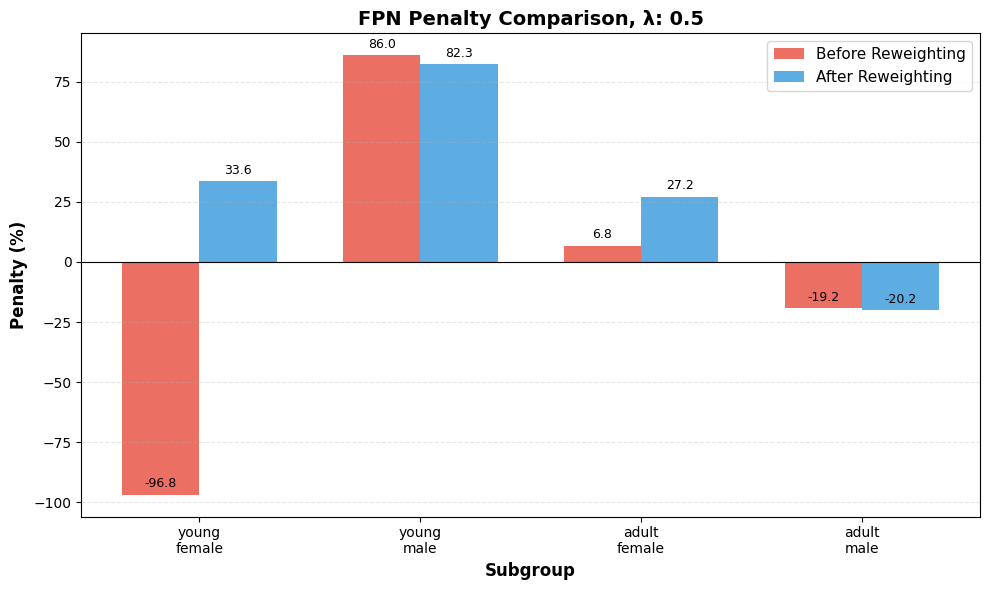


FPN - Penalty Changes:
  young-female: -96.84 → 33.59 (Δ = +130.43)
  young-male: 86.04 → 82.27 (Δ = -3.77)
  adult-female: 6.80 → 27.24 (Δ = +20.44)
  adult-male: -19.20 → -20.19 (Δ = -0.99)
------------------------------------------------------------
lambda: 1.0
Training samples: 22792, Unique weights per group: {'00': 1.1112903225806452, '01': 1.6837349397590362, '10': 1.072973578145992, '11': 0.7914111650872023}
{np.int64(1): array([[1473,  222],
       [ 246,  692]]), np.int64(0): array([[1976,    8],
       [ 174,   94]])}
{np.int64(0): array([[1408,   22],
       [  91,   89]]), np.int64(1): array([[2041,  208],
       [ 329,  697]])}
{'10': array([[612,  18],
       [ 52,  70]]), '00': array([[797,   3],
       [ 36,  22]]), '11': array([[860, 205],
       [192, 624]]), '01': array([[1180,    4],
       [ 135,   75]])}


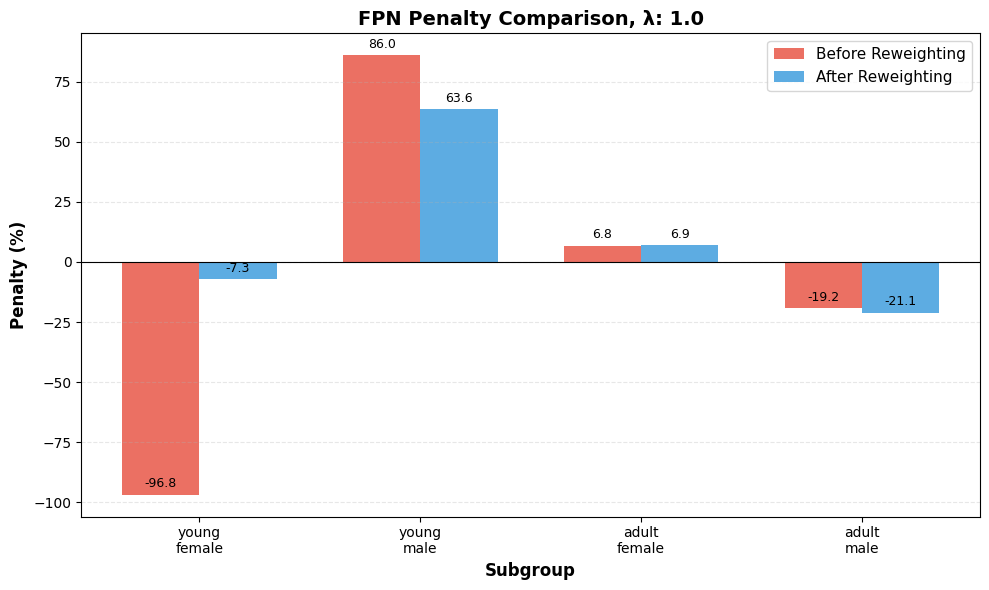


FPN - Penalty Changes:
  young-female: -96.84 → -7.26 (Δ = +89.58)
  young-male: 86.04 → 63.55 (Δ = -22.48)
  adult-female: 6.80 → 6.86 (Δ = +0.06)
  adult-male: -19.20 → -21.09 (Δ = -1.88)
------------------------------------------------------------
lambda: 2.0
Training samples: 22792, Unique weights per group: {'00': 1.2225806451612904, '01': 2.3674698795180724, '10': 1.1459471562919838, '11': 0.5828223301744047}
{np.int64(1): array([[1476,  219],
       [ 244,  694]]), np.int64(0): array([[1976,    8],
       [ 172,   96]])}
{np.int64(0): array([[1407,   23],
       [  89,   91]]), np.int64(1): array([[2045,  204],
       [ 327,  699]])}
{'10': array([[611,  19],
       [ 51,  71]]), '00': array([[796,   4],
       [ 39,  19]]), '11': array([[861, 204],
       [193, 623]]), '01': array([[1178,    6],
       [ 135,   75]])}


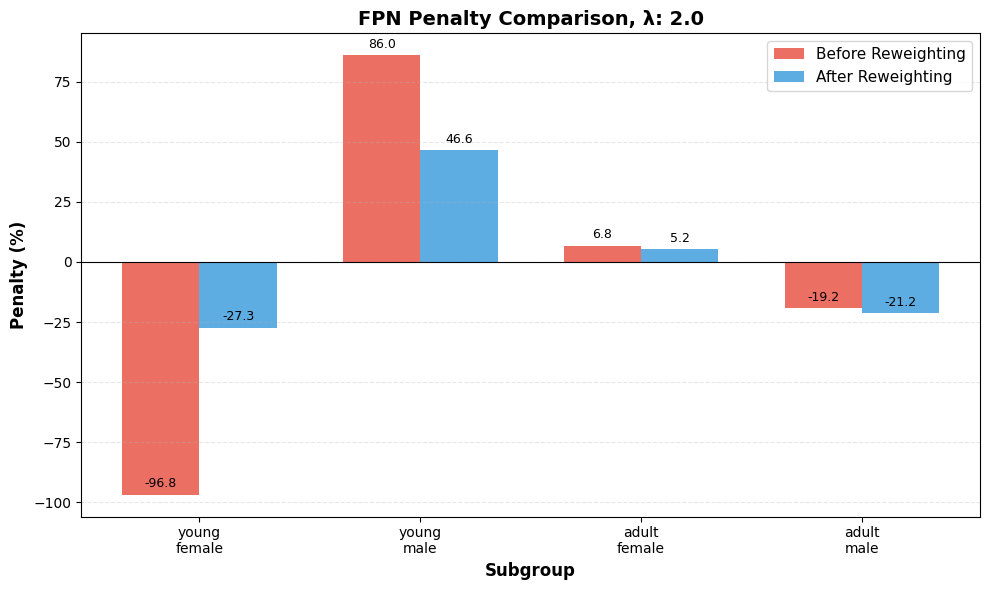


FPN - Penalty Changes:
  young-female: -96.84 → -27.30 (Δ = +69.54)
  young-male: 86.04 → 46.59 (Δ = -39.45)
  adult-female: 6.80 → 5.22 (Δ = -1.58)
  adult-male: -19.20 → -21.19 (Δ = -1.99)
------------------------------------------------------------
lambda: 5.0
Training samples: 22792, Unique weights per group: {'00': 1.5564516129032262, '01': 4.418674698795181, '10': 1.3648678907299594, '11': 0.01}
{np.int64(1): array([[1473,  222],
       [ 264,  674]]), np.int64(0): array([[1973,   11],
       [ 171,   97]])}
{np.int64(0): array([[1409,   21],
       [  88,   92]]), np.int64(1): array([[2037,  212],
       [ 347,  679]])}
{'10': array([[611,  19],
       [ 51,  71]]), '00': array([[797,   3],
       [ 37,  21]]), '11': array([[864, 201],
       [208, 608]]), '01': array([[1172,   12],
       [ 130,   80]])}


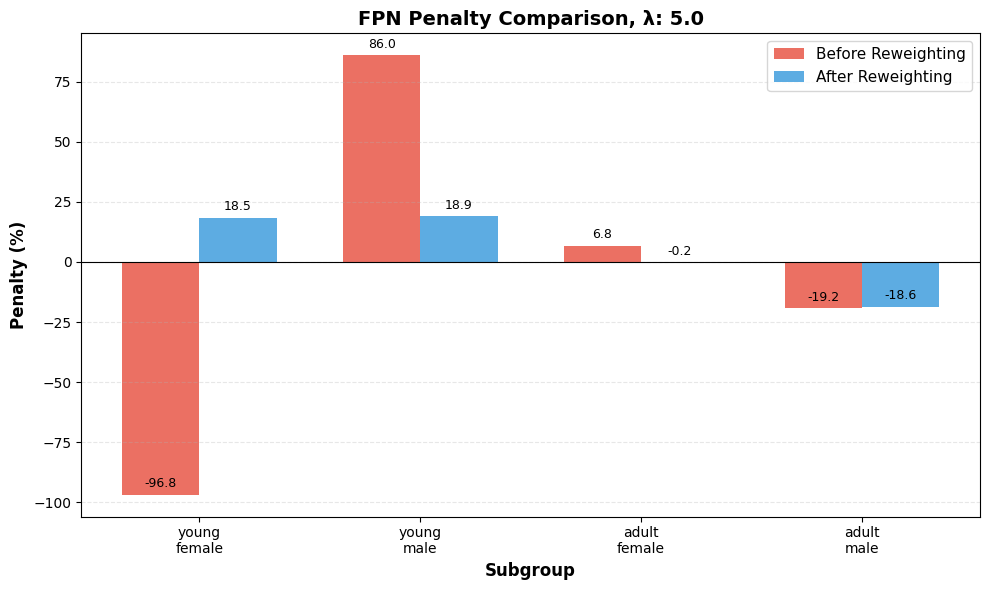


FPN - Penalty Changes:
  young-female: -96.84 → 18.49 (Δ = +115.33)
  young-male: 86.04 → 18.95 (Δ = -67.09)
  adult-female: 6.80 → -0.15 (Δ = -6.95)
  adult-male: -19.20 → -18.58 (Δ = +0.62)
------------------------------------------------------------
lambda: 10.0
Training samples: 22792, Unique weights per group: {'00': 2.1129032258064524, '01': 7.837349397590361, '10': 1.7297357814599188, '11': 0.01}
{np.int64(1): array([[1469,  226],
       [ 261,  677]]), np.int64(0): array([[1971,   13],
       [ 175,   93]])}
{np.int64(0): array([[1406,   24],
       [  91,   89]]), np.int64(1): array([[2034,  215],
       [ 345,  681]])}
{'10': array([[611,  19],
       [ 51,  71]]), '00': array([[797,   3],
       [ 37,  21]]), '11': array([[853, 212],
       [213, 603]]), '01': array([[1174,   10],
       [ 135,   75]])}


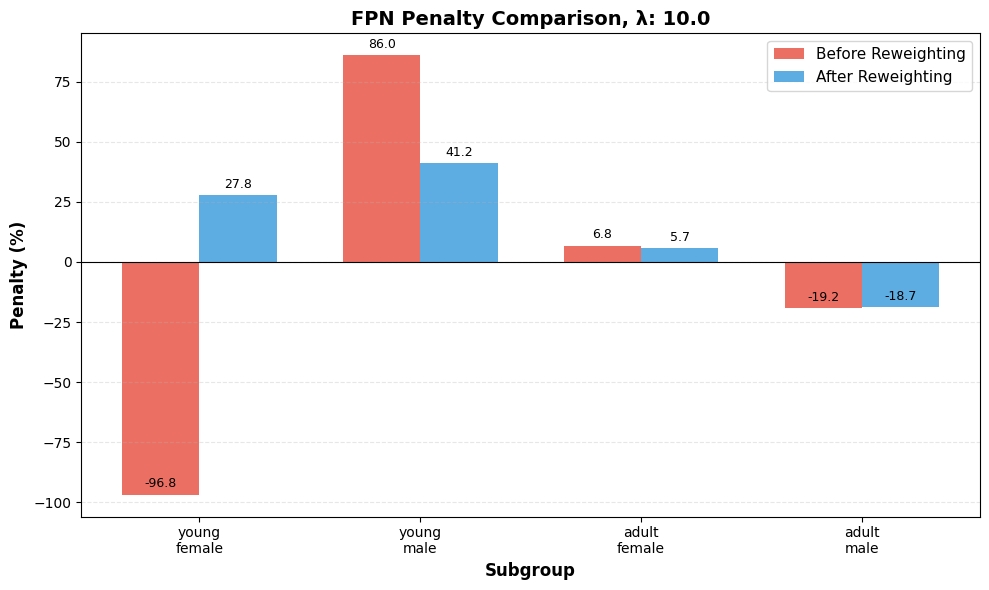


FPN - Penalty Changes:
  young-female: -96.84 → 27.80 (Δ = +124.64)
  young-male: 86.04 → 41.15 (Δ = -44.89)
  adult-female: 6.80 → 5.73 (Δ = -1.07)
  adult-male: -19.20 → -18.71 (Δ = +0.49)
------------------------------------------------------------


In [672]:
for l in lambdas:
    weights_notsized = compute_weights_notsized(l, 'FPN', penalties_onval, X_train, sensible_attribute)
    penalties_ontest_after_reweighting['FPN']= compute_penalties_after_reweighting(weights_notsized, 'FPN', dataset_path, sensible_attribute, X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels) # Get only harmonic penalty

    plot_penalty_comparison_all_individual(['FPN'], penalties_ontest, penalties_ontest_after_reweighting, 
                                            sensible_attribute, mapping, l)